In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def read_arm():
    # 读取CSV文件
    df = pd.read_csv('data_0.csv')
    return df

def calculate_std(data):
    return data.std()

In [3]:
arm = read_arm()

In [4]:
Bx = arm['磁场X(ʯt)'].to_numpy()
By = arm['磁场Y(ʯt)'].to_numpy()
Bz = arm['磁场Z(ʯt)'].to_numpy()
B = arm['磁场矢量和(ʯt)'].to_numpy()

In [5]:
std_x = []
std_y = []
std_z = []
std_B = []
for i in range(len(Bx)):
    std_x.append(calculate_std(Bx[i:i+20]))
    std_y.append(calculate_std(By[i:i+20]))
    std_z.append(calculate_std(Bz[i:i+20]))
    std_B.append(calculate_std(B[i:i+20]))
    
std_x_np = np.array(std_x).reshape(-1,1)
std_y_np = np.array(std_y).reshape(-1,1)
std_z_np = np.array(std_z).reshape(-1,1)
std_B_np = np.array(std_B).reshape(-1,1)
std_np = np.concatenate([std_x_np, std_y_np, std_z_np, std_B_np], axis=1)

In [6]:
np.savetxt('output_0.csv', std_np, delimiter=',')

print("NumPy 数组已保存为 output.csv 文件")

NumPy 数组已保存为 output.csv 文件


In [7]:
steps = []
sub_steps = []
skip_flag = 0
for i in range(len(Bx)):
    if std_x[i]<5e-2 and std_y[i]<5e-2 and std_z[i]<5e-2 and std_B[i]<5e-2:
        if std_x[i]<2e-2 and std_y[i]<2e-2 and std_z[i]<2e-2 and std_B[i]<2e-2:
            sub_steps.append([i, Bx[i], By[i], Bz[i], B[i], std_x[i], std_y[i], std_z[i], std_B[i]])
        skip_flag = 0
        continue
    if skip_flag==0 and (std_x[i]>5e-2 or std_y[i]>5e-2 or std_z[i]>5e-2 or std_B[i]>5e-2):        
        if(len(sub_steps)==0):
            continue
        steps.append(sub_steps)
        print(len(steps), len(sub_steps))
        sub_steps = []
        skip_flag = 1
        continue
    if skip_flag==1:
        if std_x[i]>5e-2 or std_y[i]>5e-2 or std_z[i]>5e-2 or std_B[i]>5e-2:
            continue            
        else:
            skip_flag = 0
            sub_steps.append([i, Bx[i], By[i], Bz[i], B[i], std_x[i], std_y[i], std_z[i], std_B[i]])

1 183
2 76
3 81
4 82
5 80
6 78
7 79
8 79
9 82
10 81
11 78
12 74
13 78
14 76
15 79
16 65
17 78
18 81
19 83
20 83
21 83
22 76
23 82
24 77
25 81
26 74
27 81
28 82
29 86
30 81
31 81
32 79
33 85
34 82
35 73
36 79
37 76
38 82
39 74
40 72
41 80
42 82
43 84
44 74
45 81
46 79
47 80
48 81
49 78
50 80
51 76
52 80
53 50
54 83
55 79
56 76
57 67
58 82
59 83
60 81
61 81
62 80
63 76
64 82
65 81
66 79
67 82
68 83
69 88
70 73
71 82
72 80
73 83
74 84
75 79
76 74
77 62
78 70
79 83
80 81
81 79
82 78
83 79
84 84
85 81
86 59
87 82
88 80
89 84
90 75
91 81
92 81
93 80
94 82
95 84
96 81
97 79
98 79
99 64
100 74
101 81
102 42
103 83
104 74
105 82
106 66
107 61
108 83
109 84
110 84
111 80
112 79
113 82
114 92
115 84
116 78
117 80
118 83
119 84
120 81
121 79
122 72
123 82
124 60
125 79
126 79


0


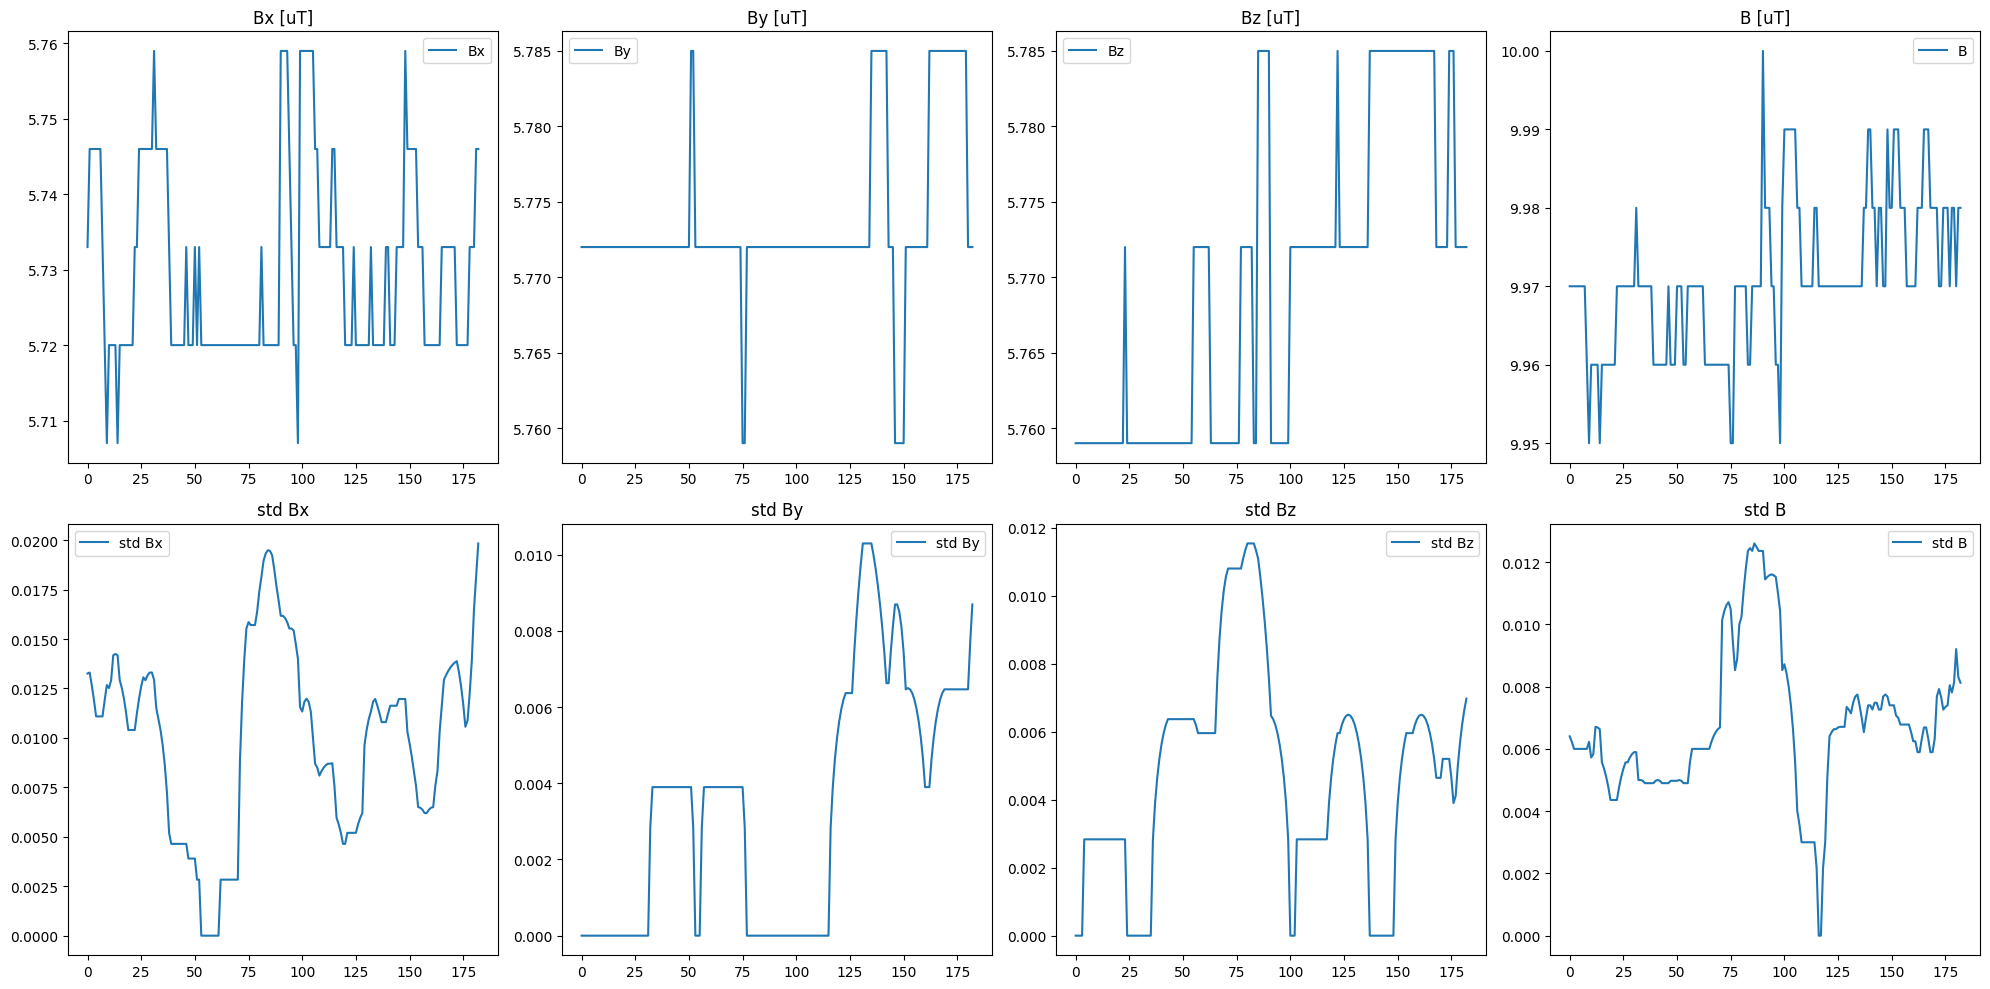

1


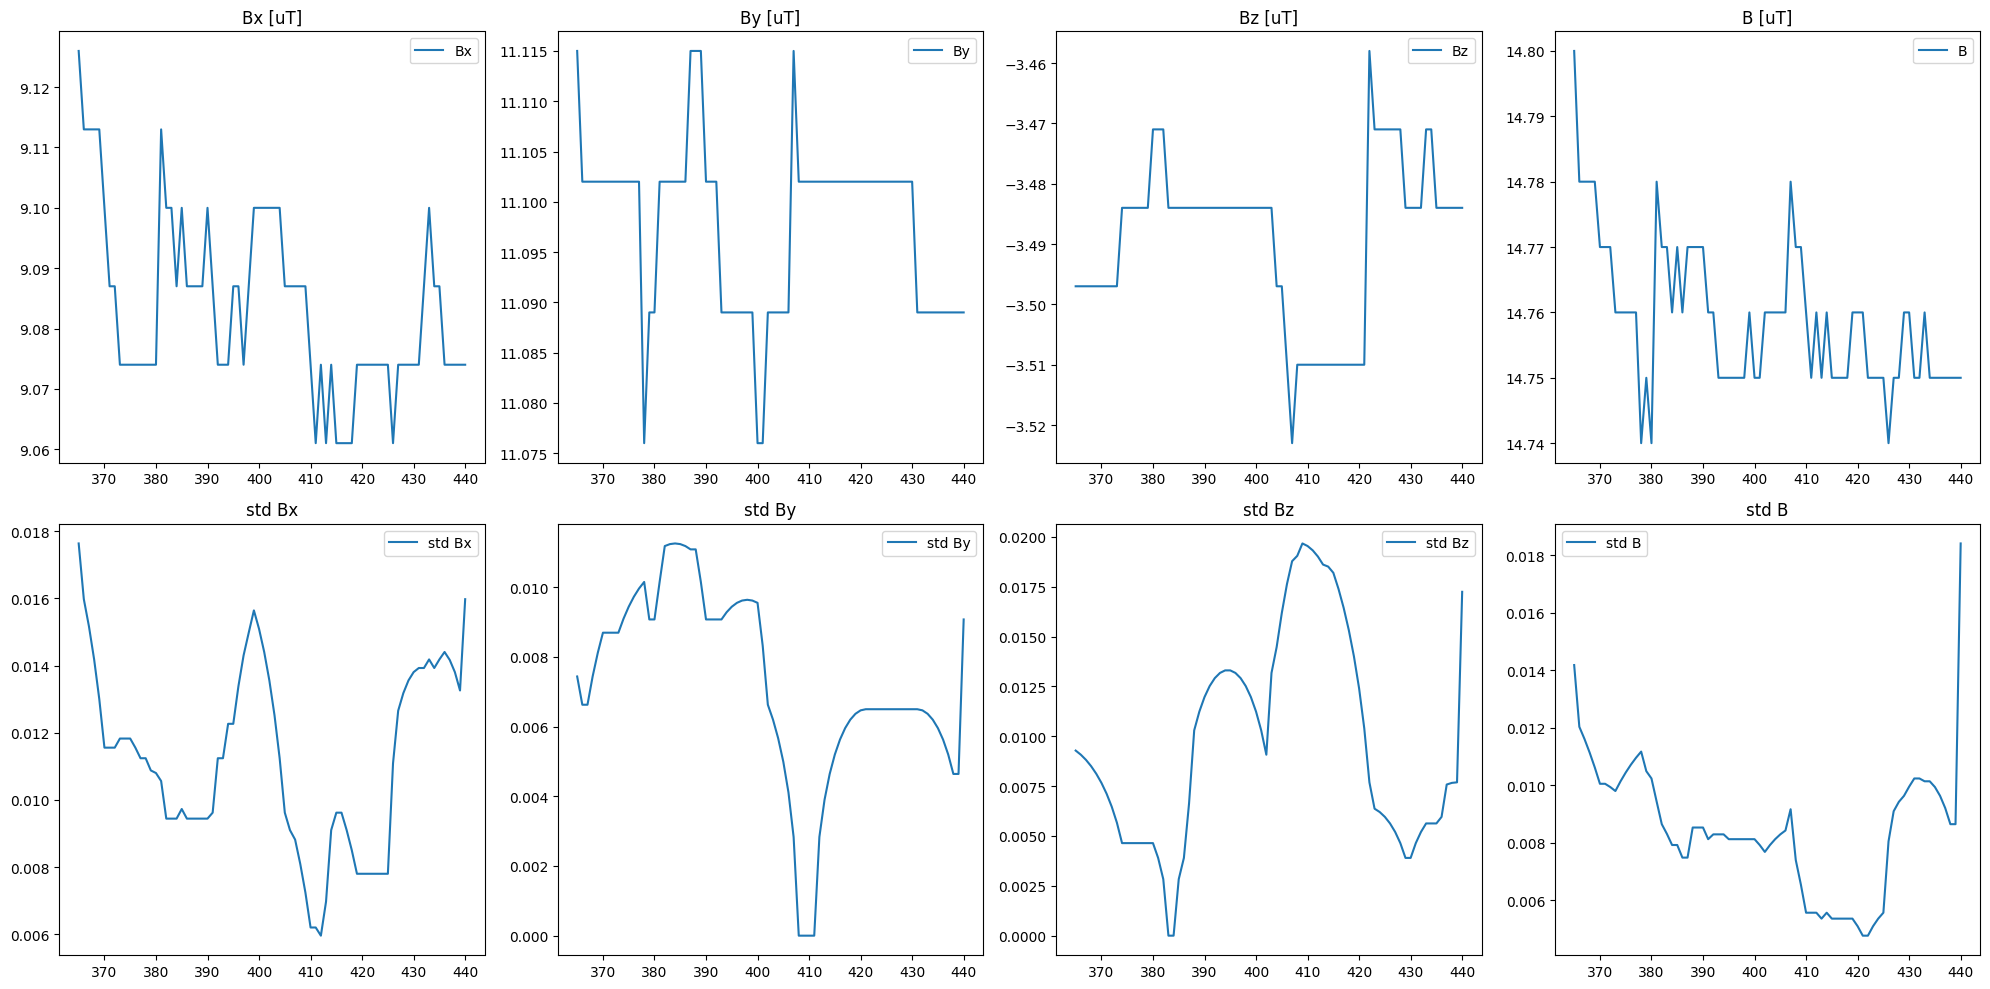

2


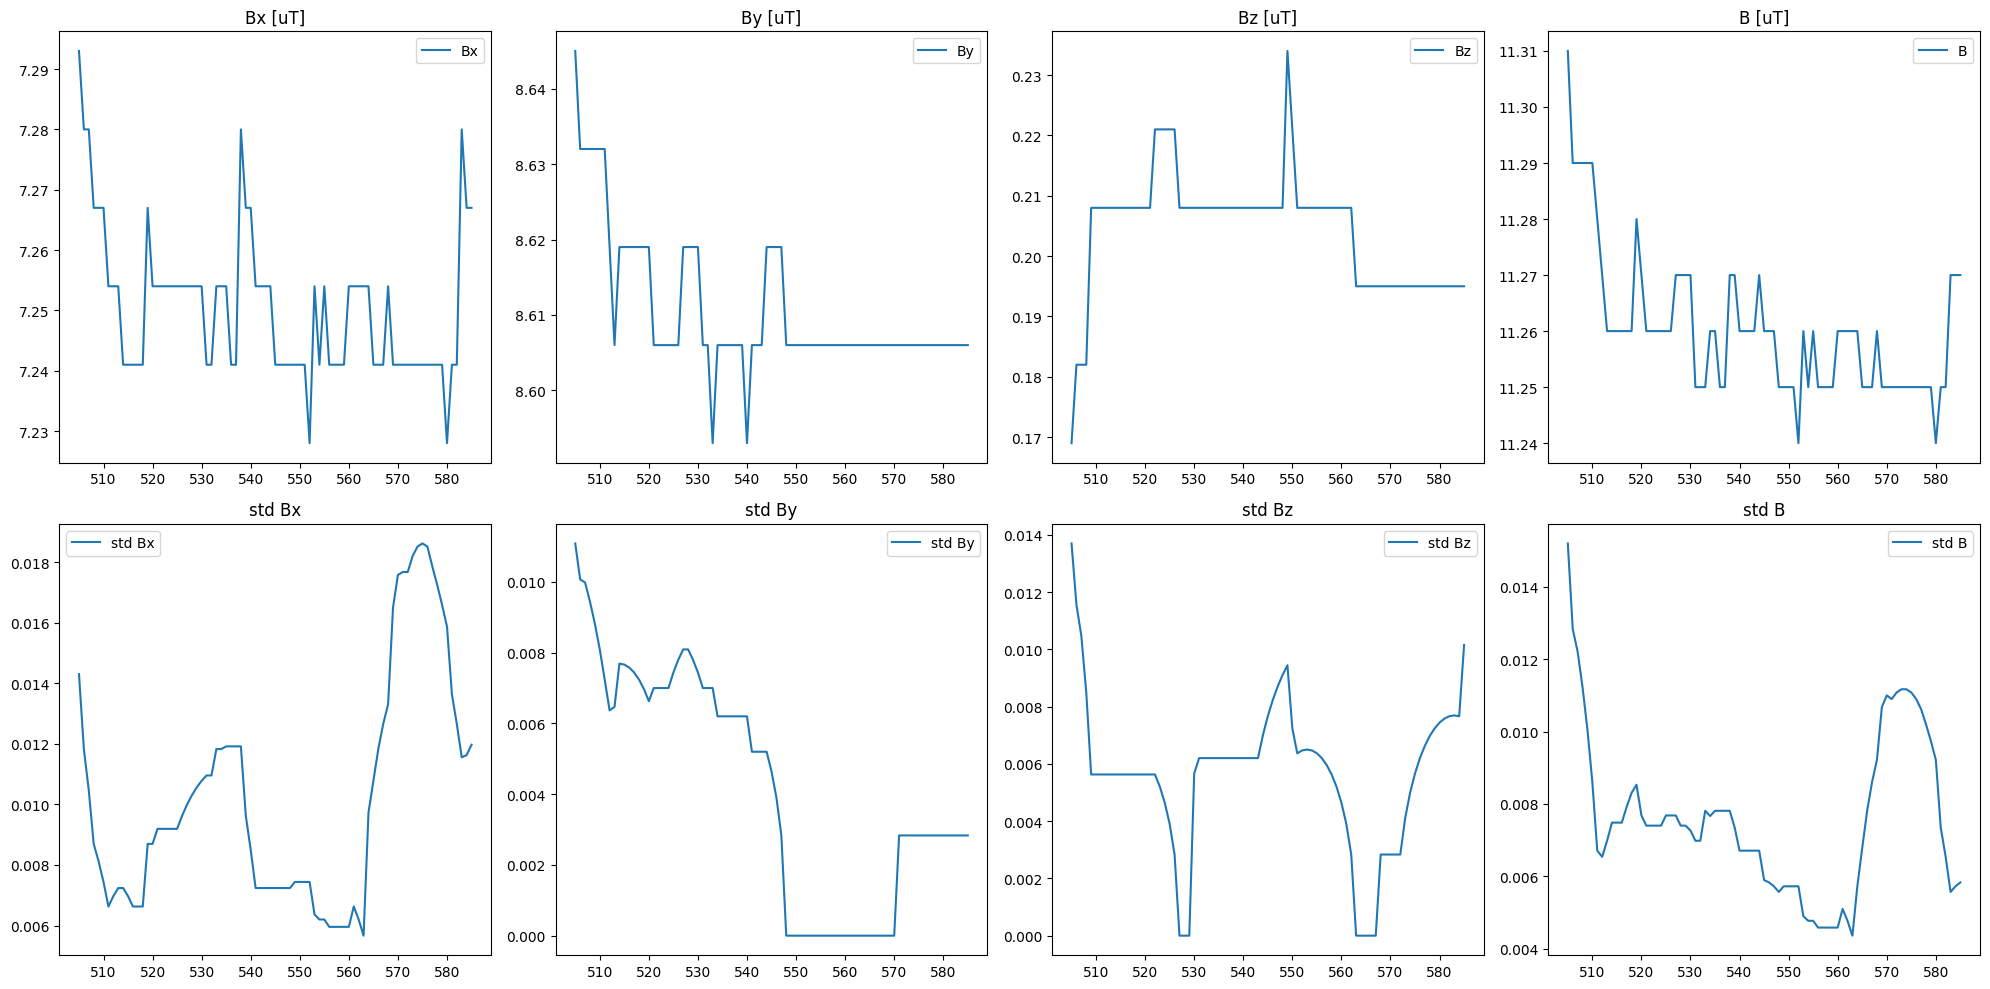

3


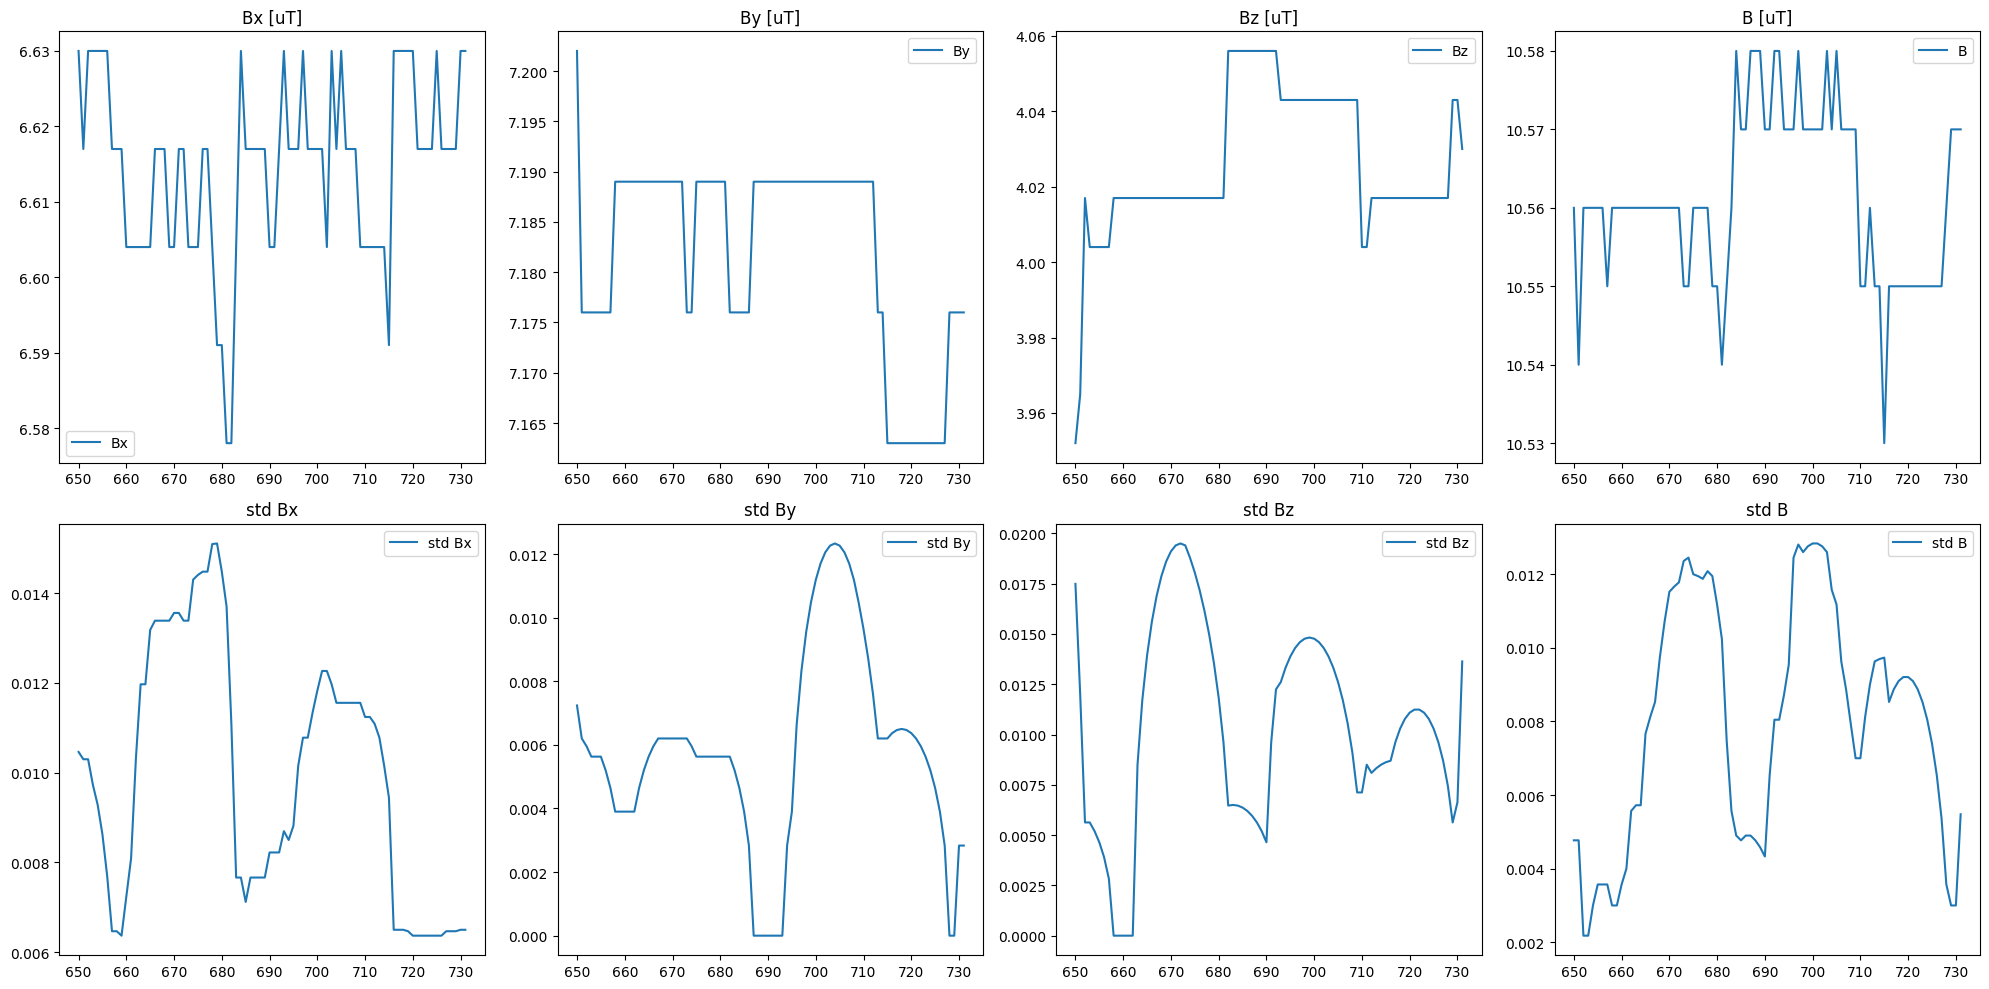

4


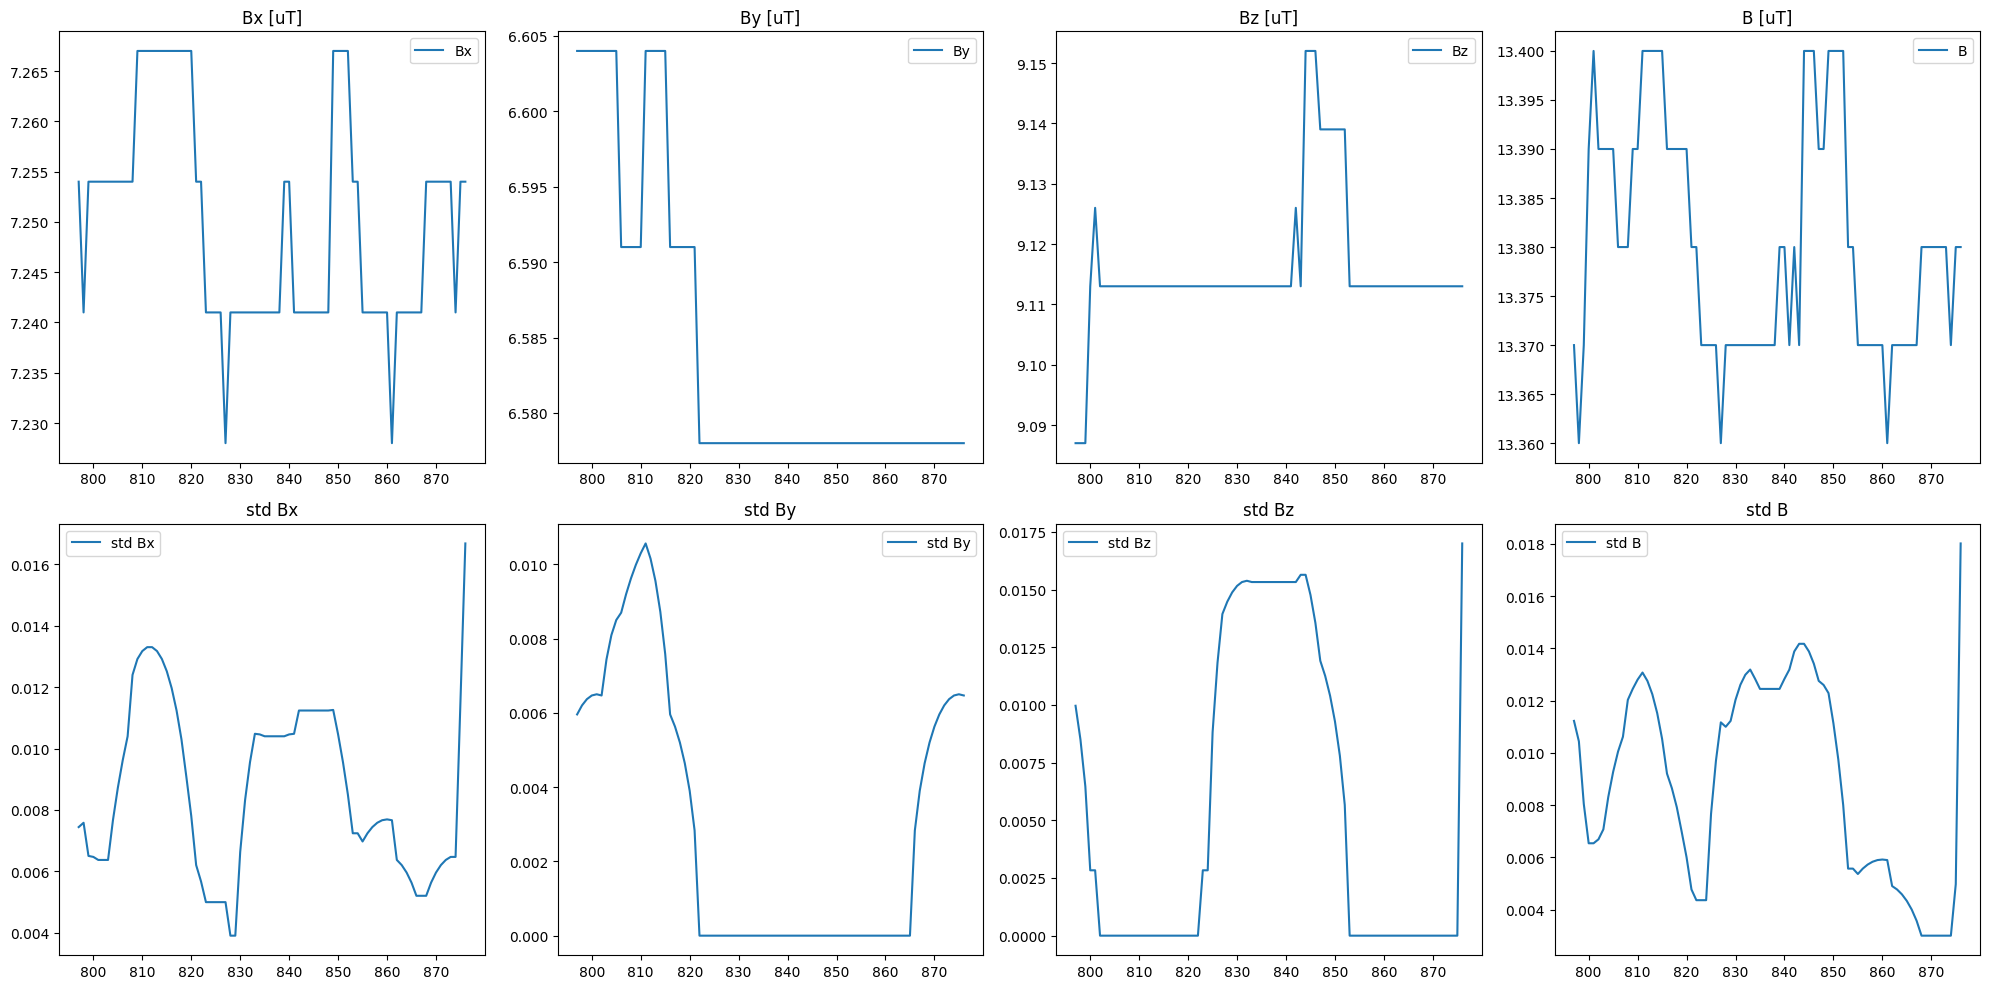

5


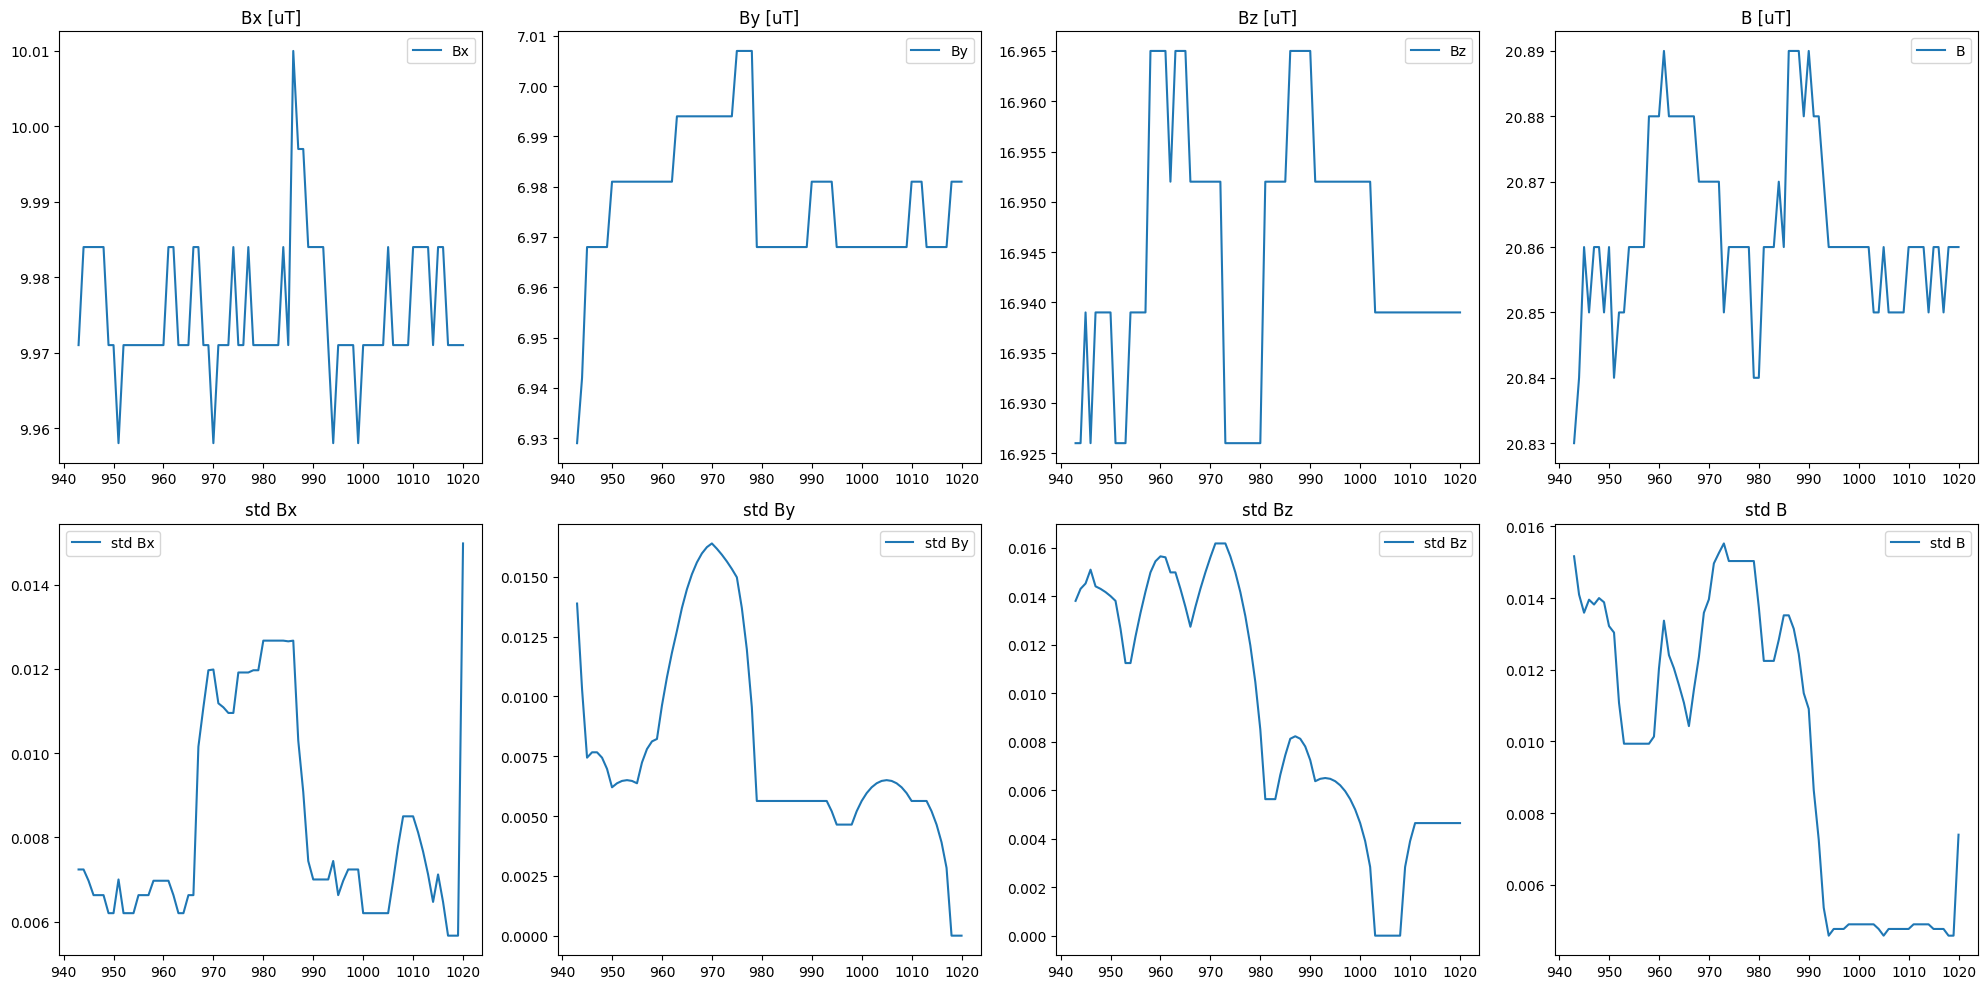

6


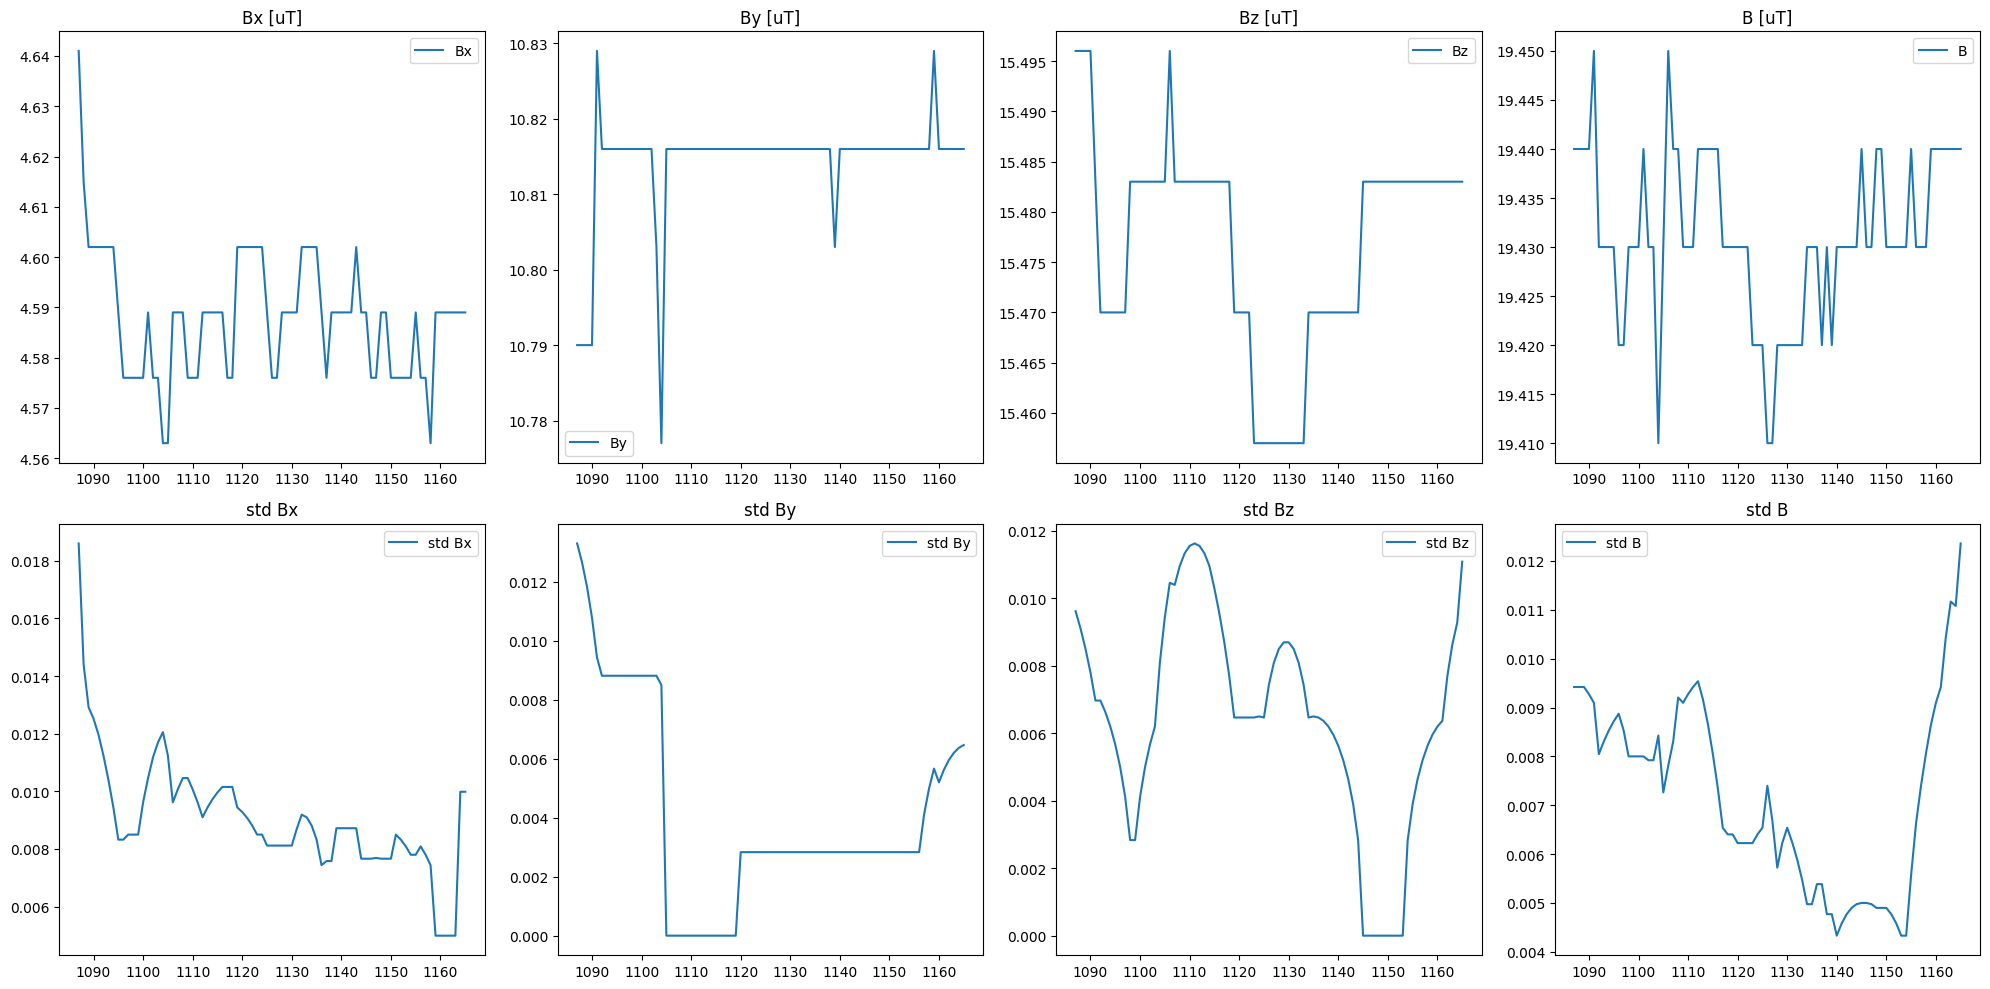

7


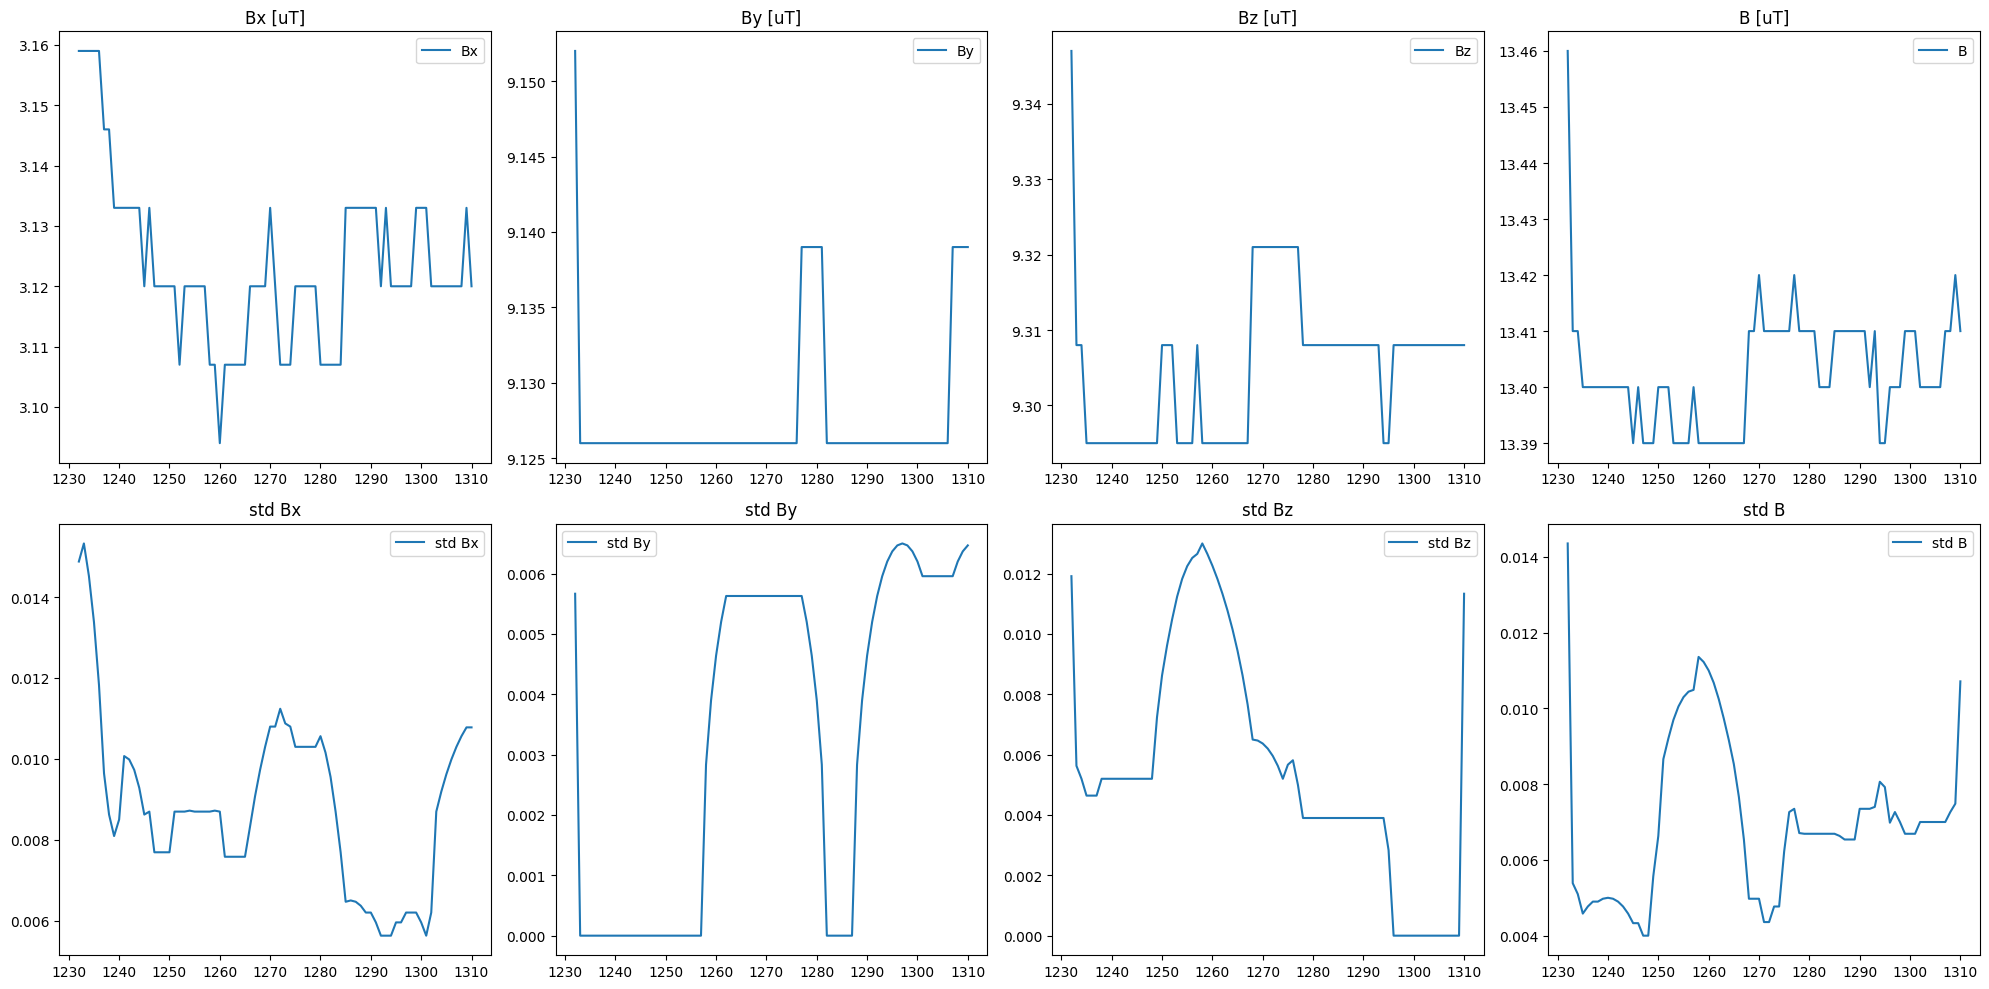

8


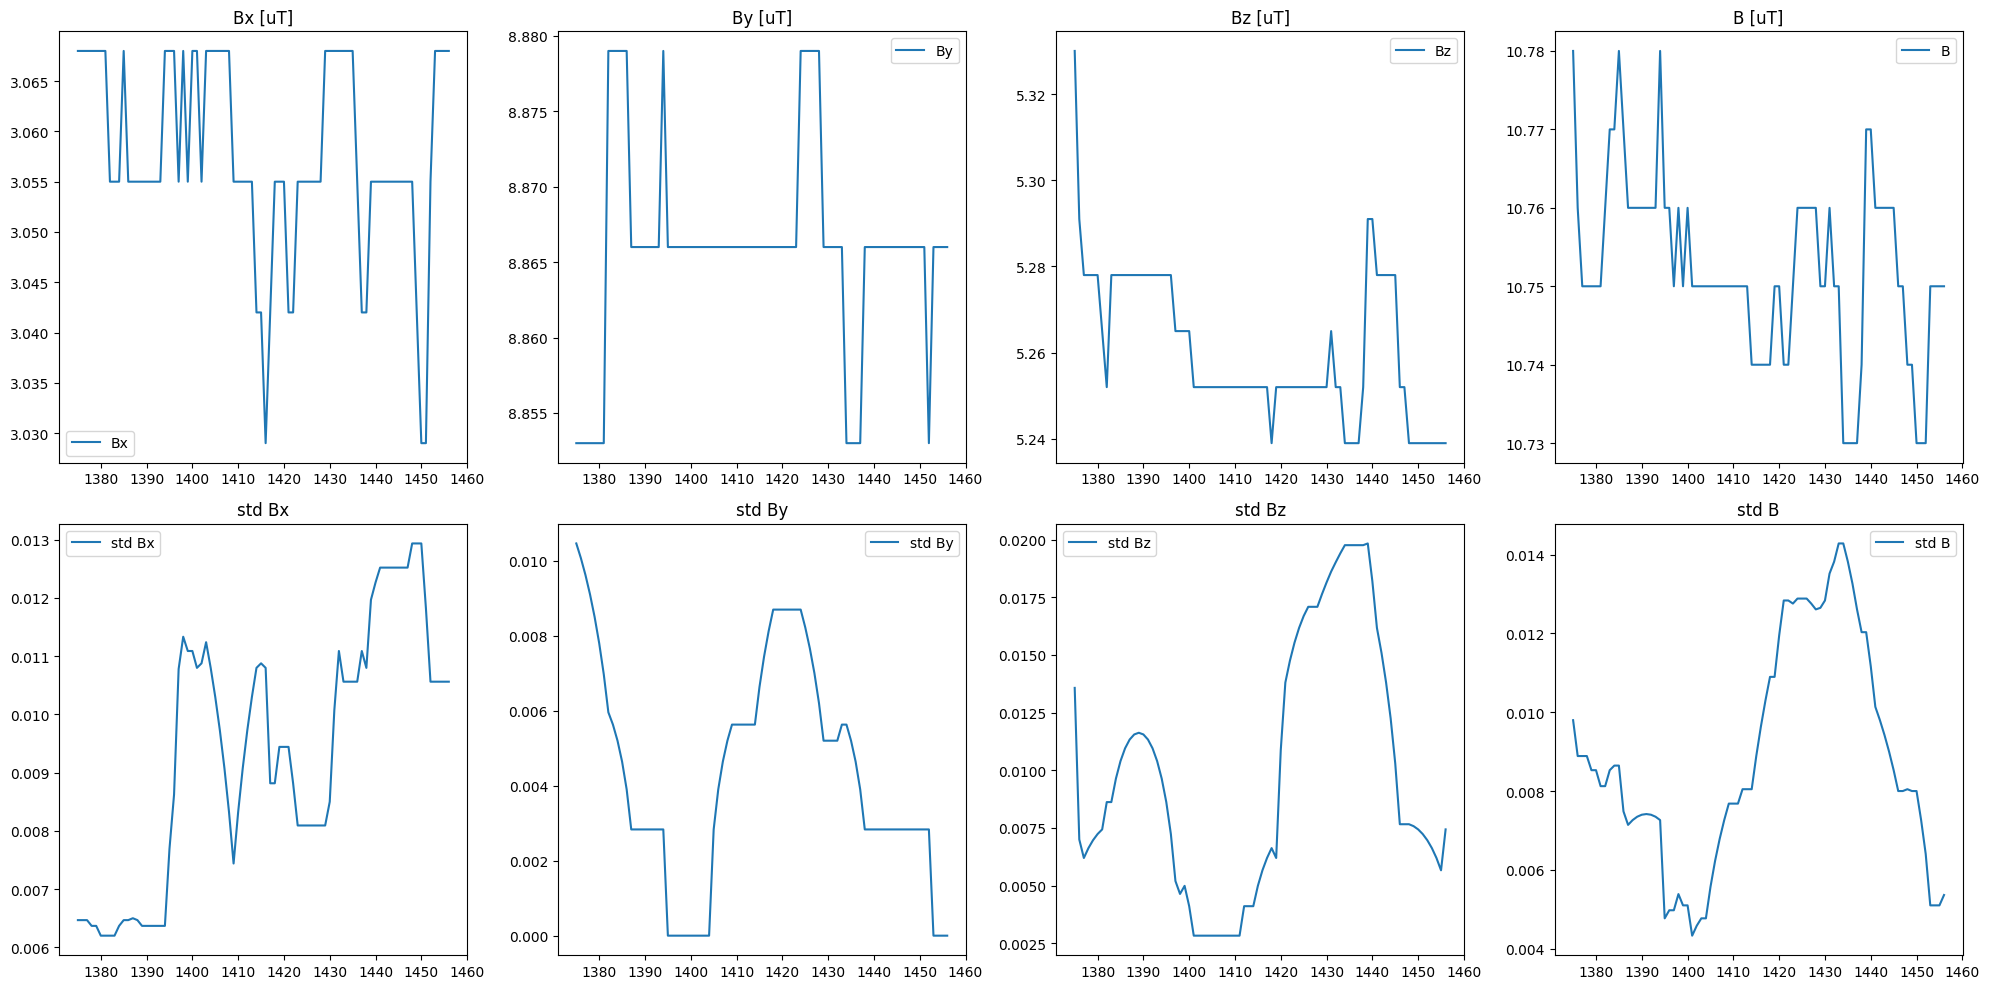

9


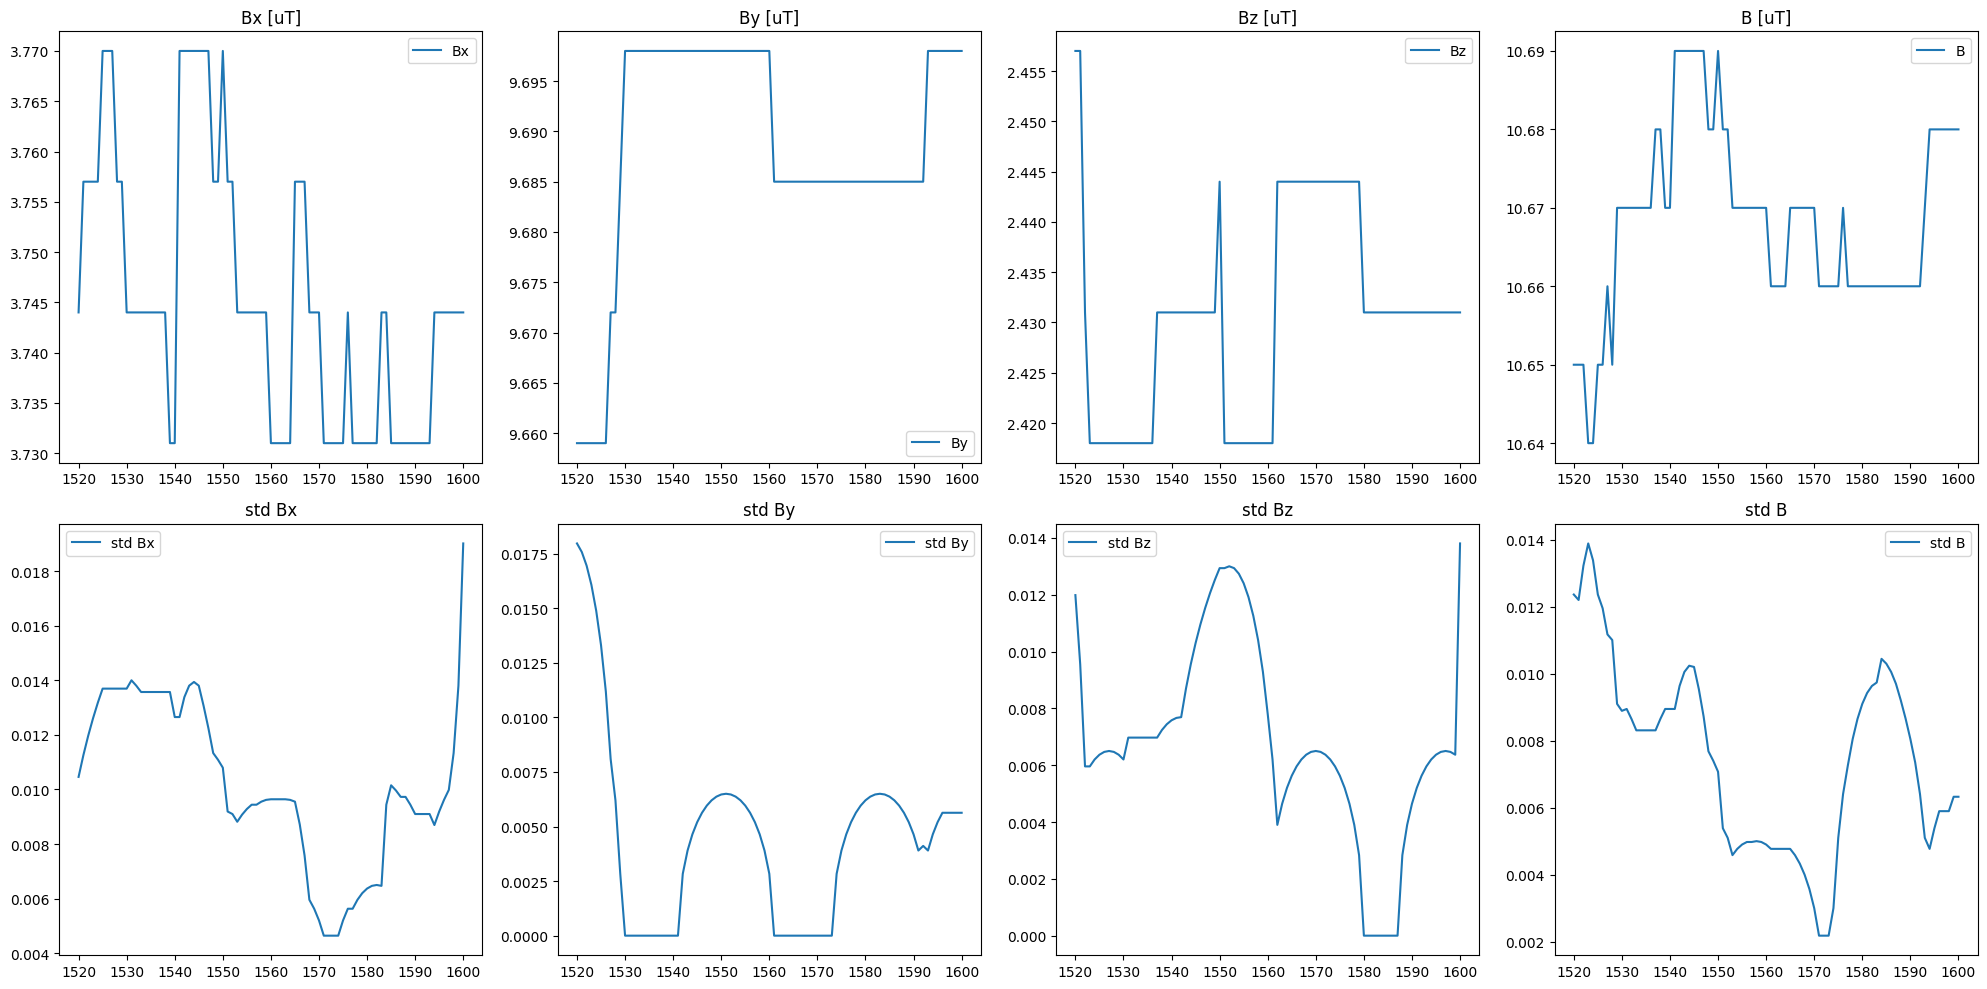

10


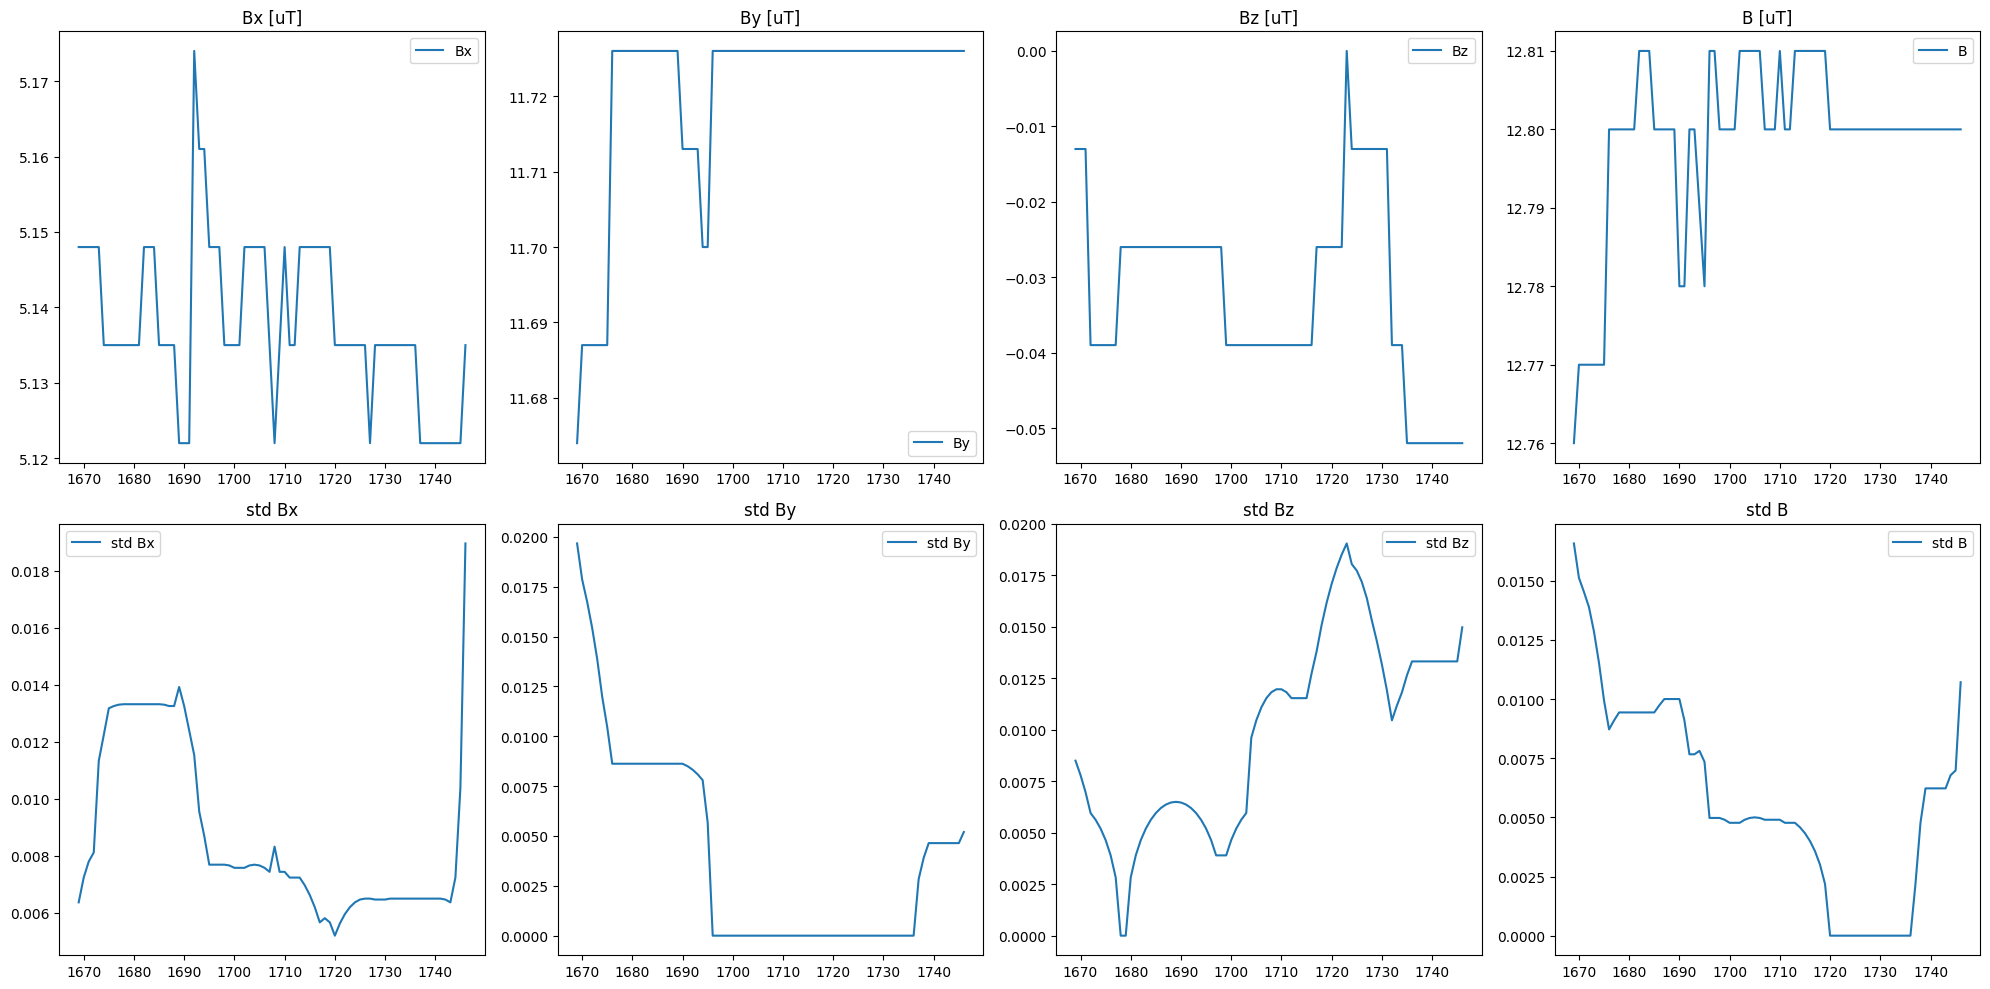

11


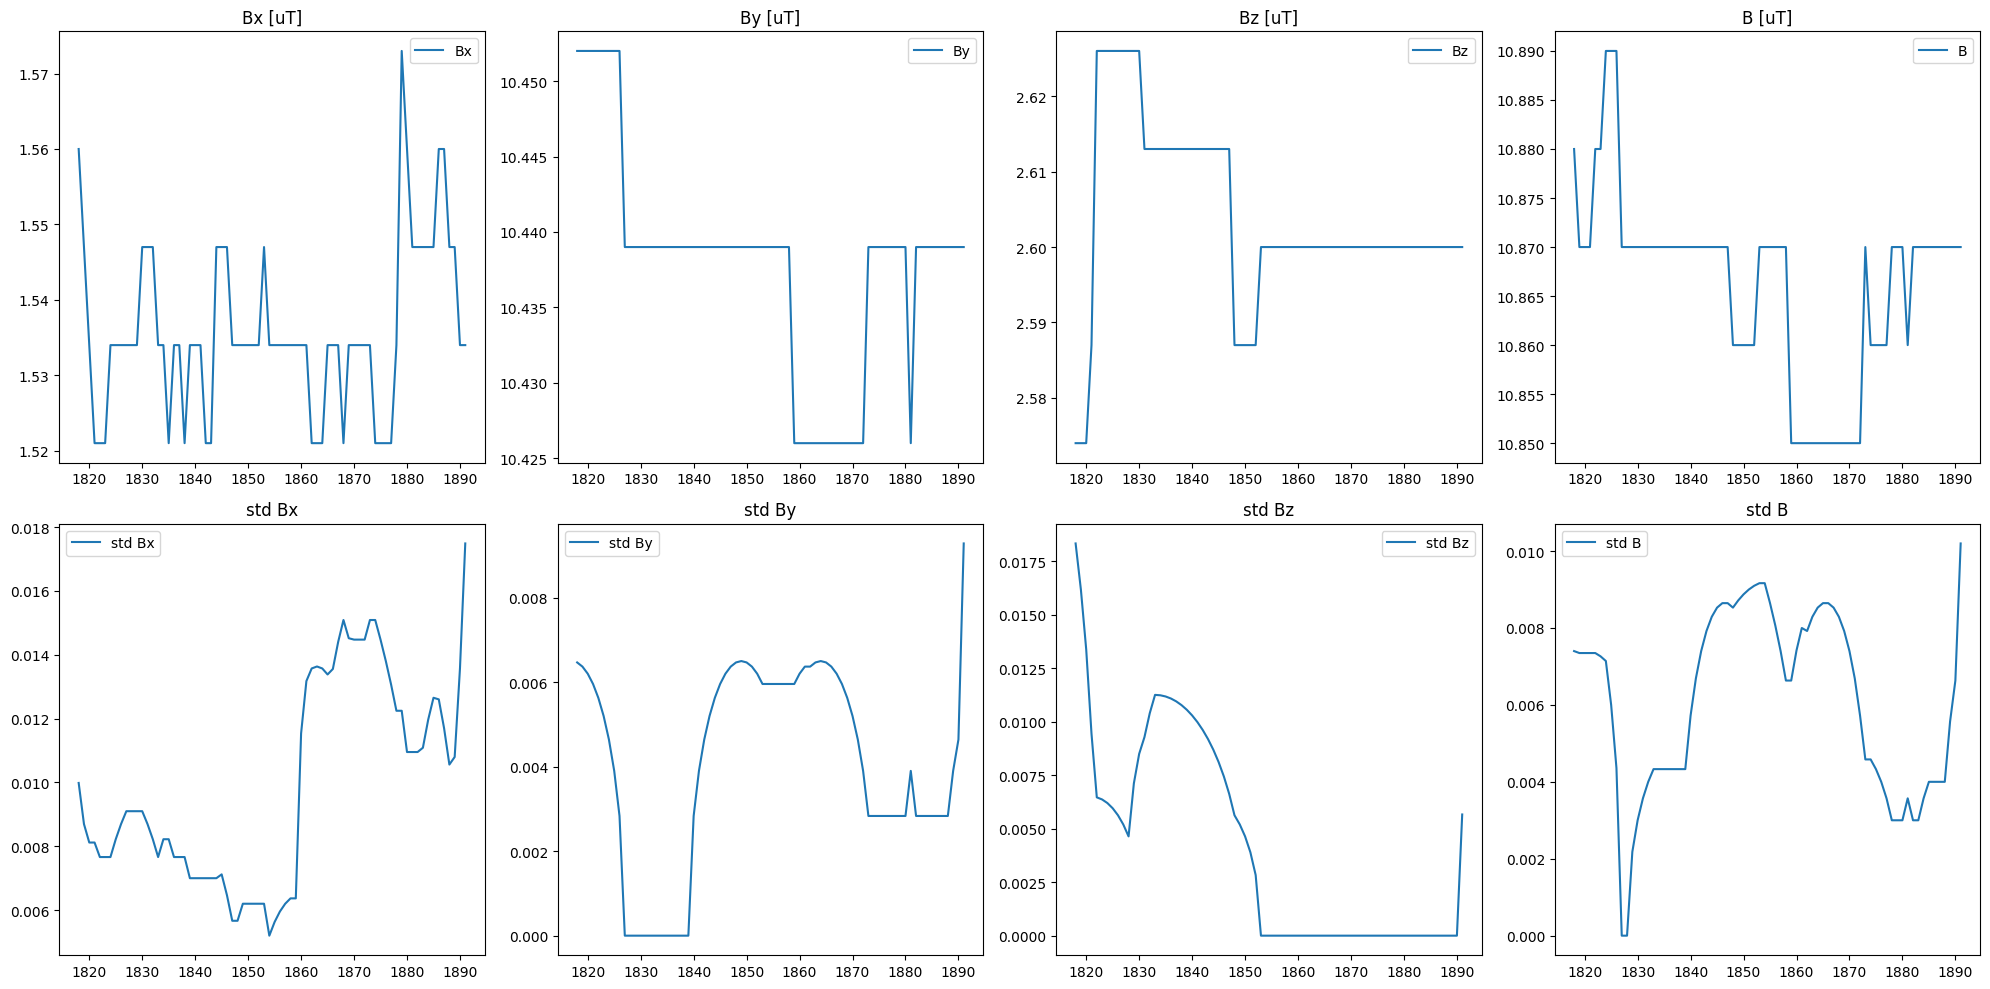

12


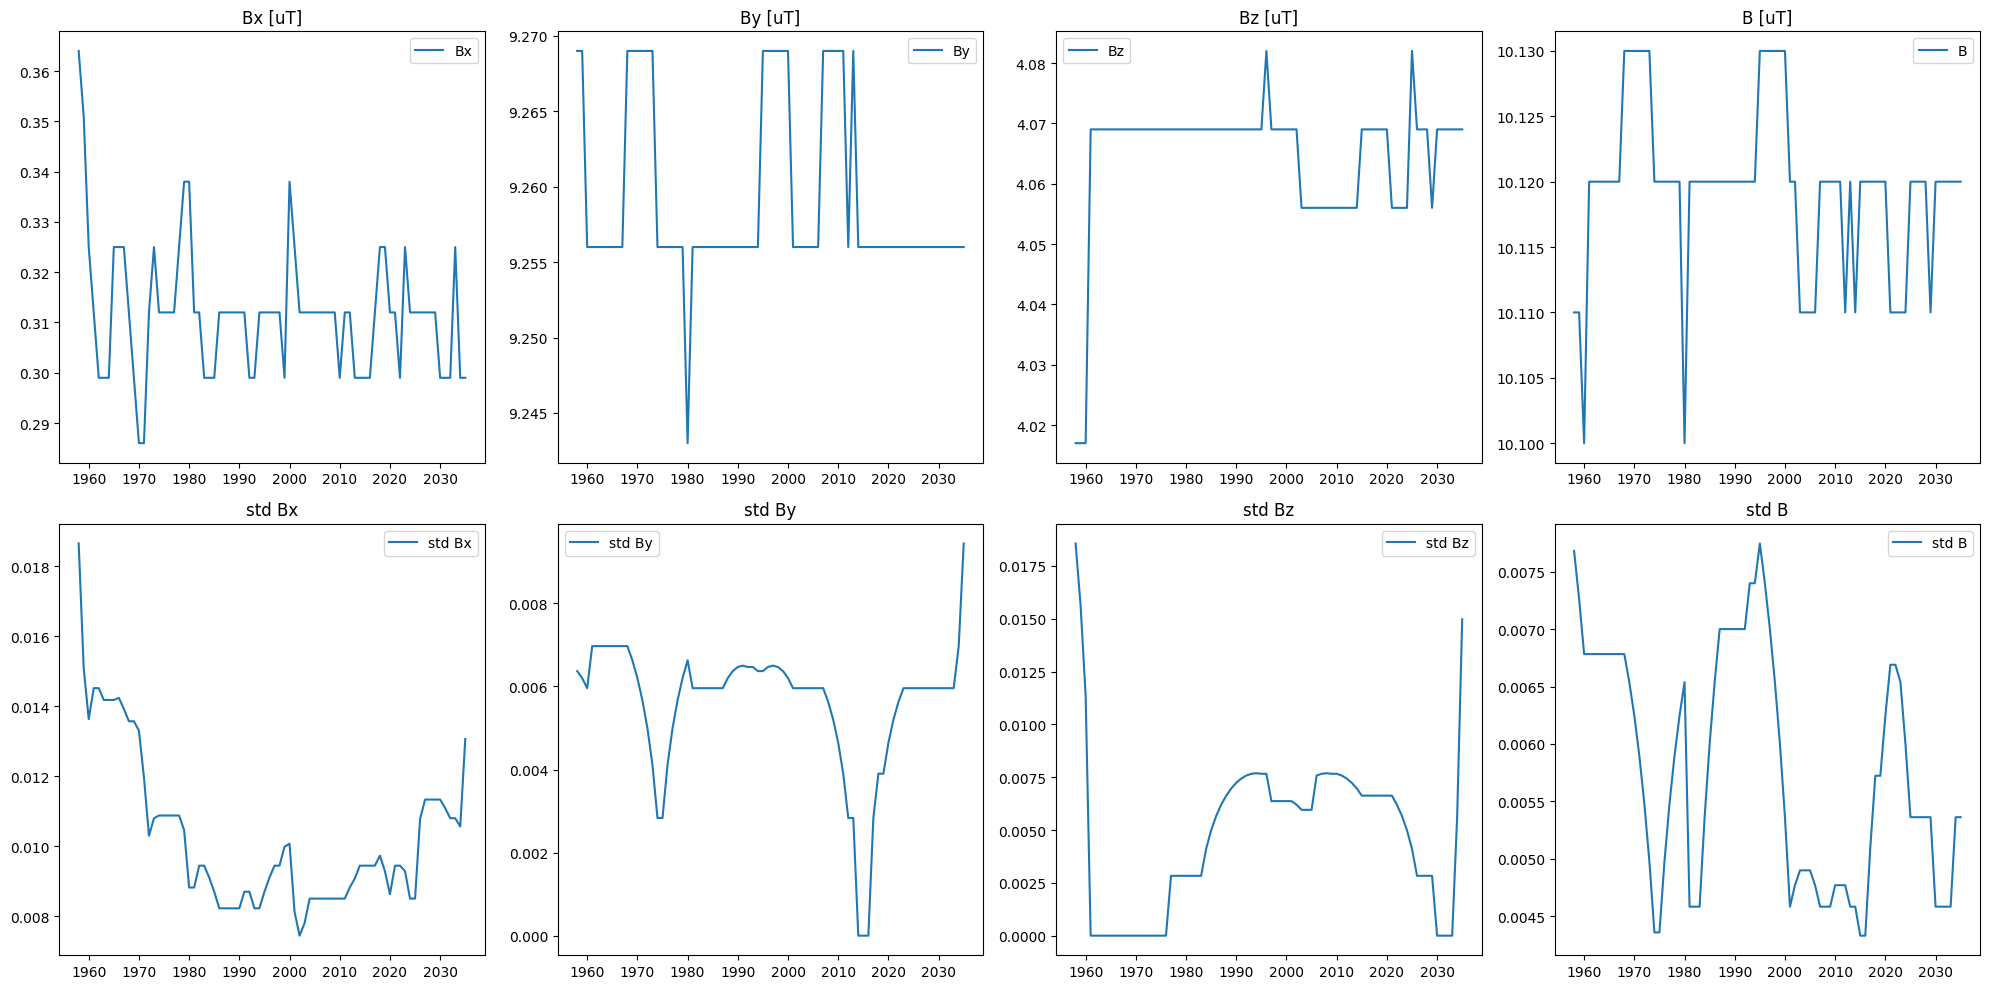

13


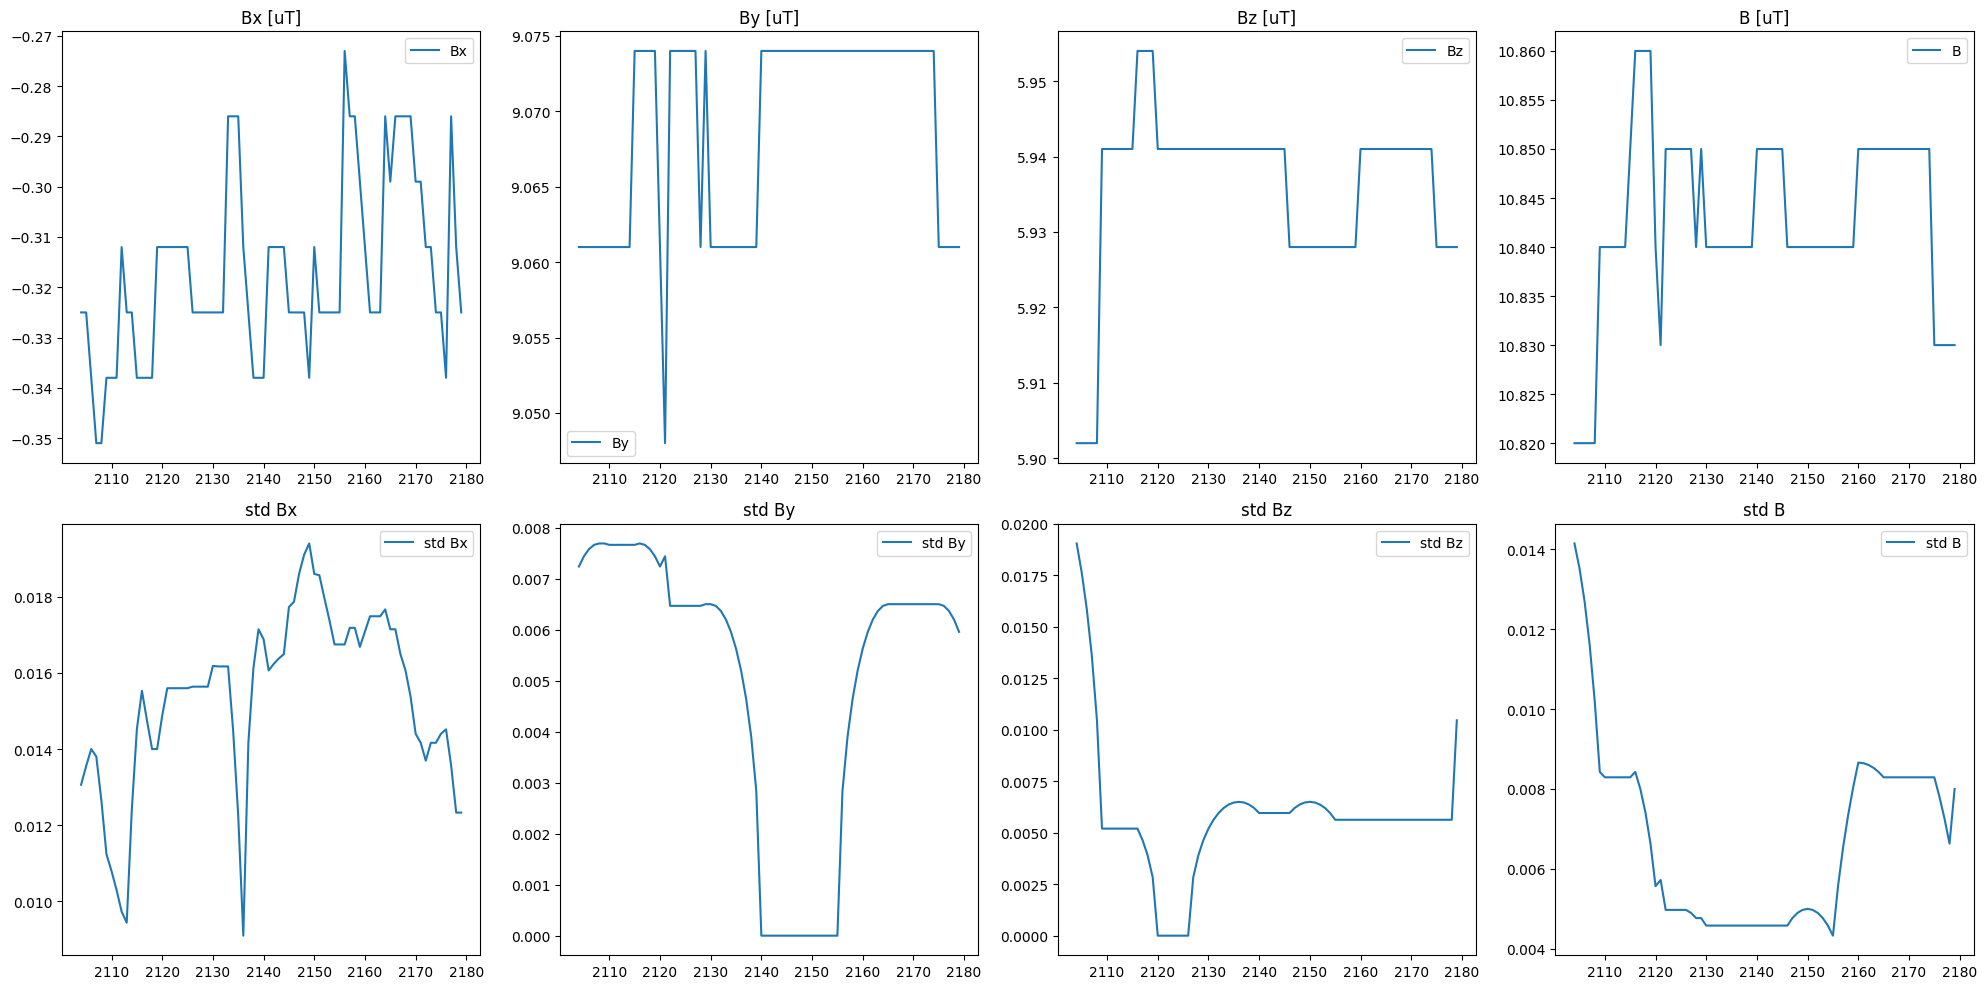

14


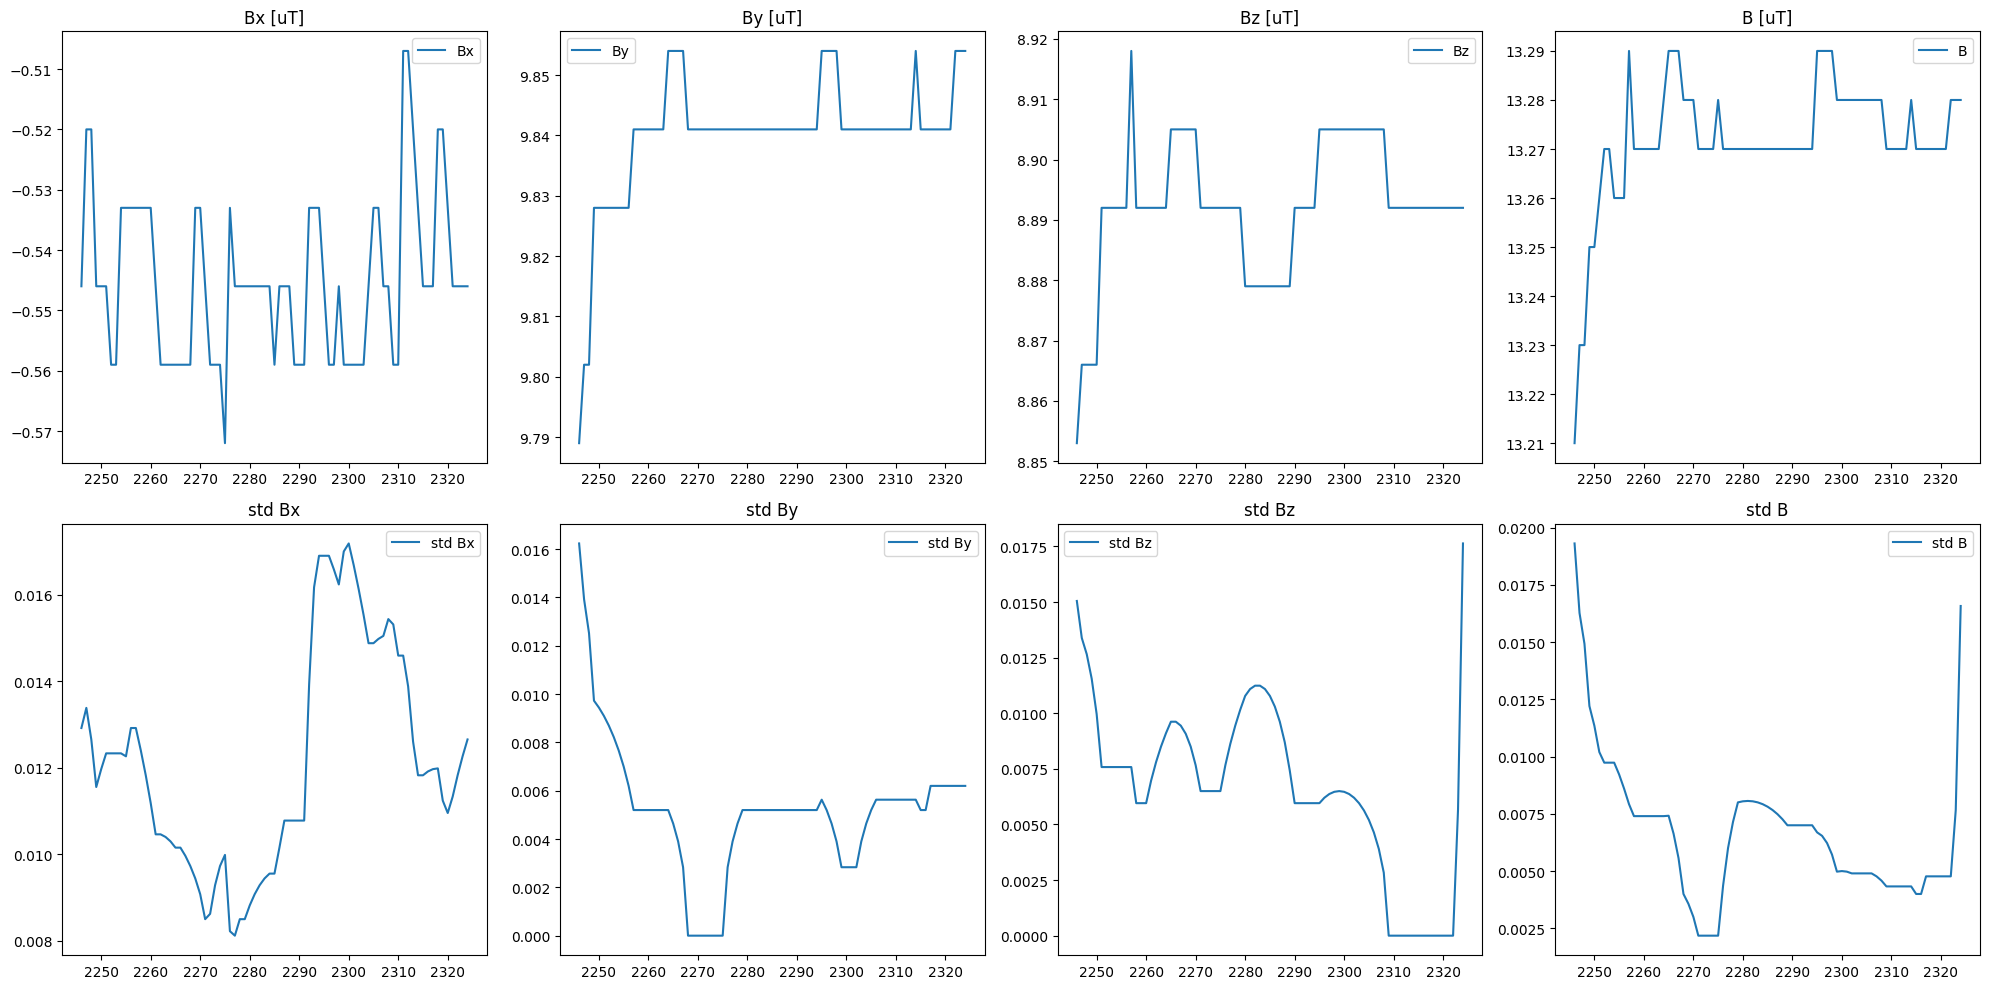

15


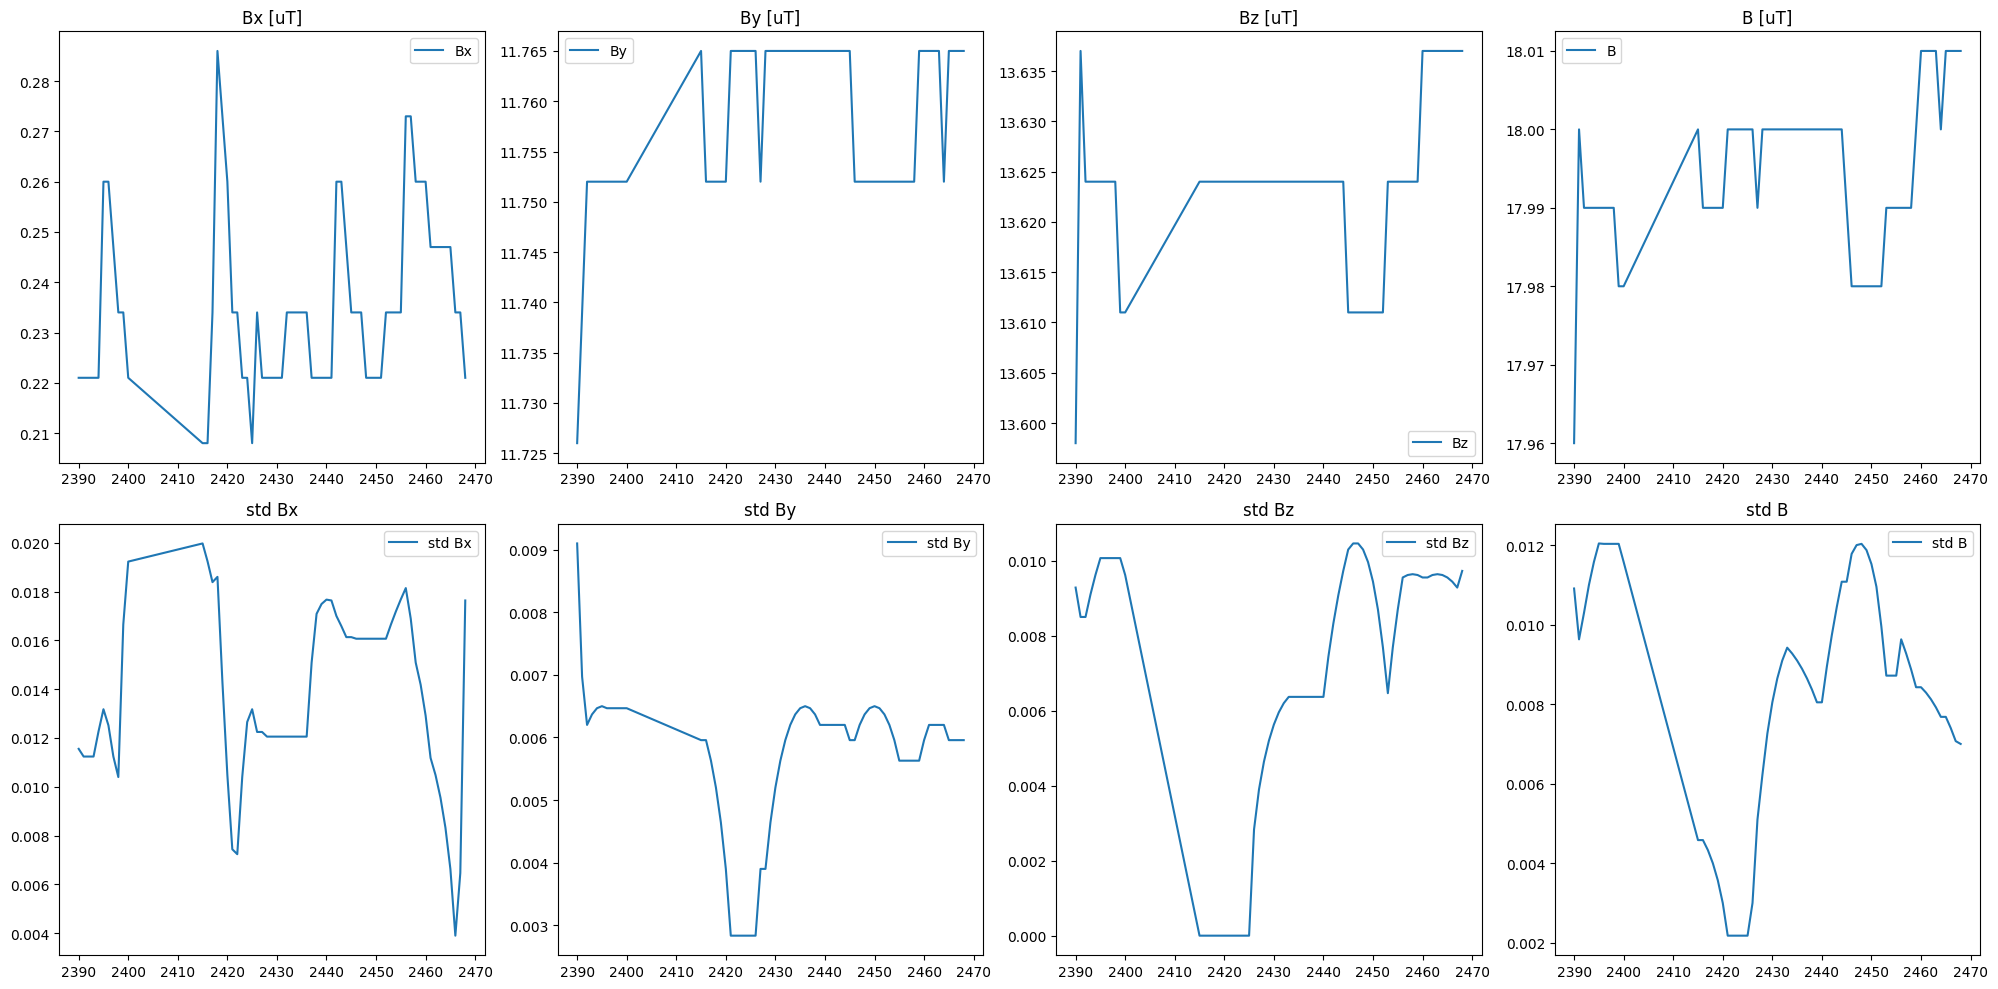

16


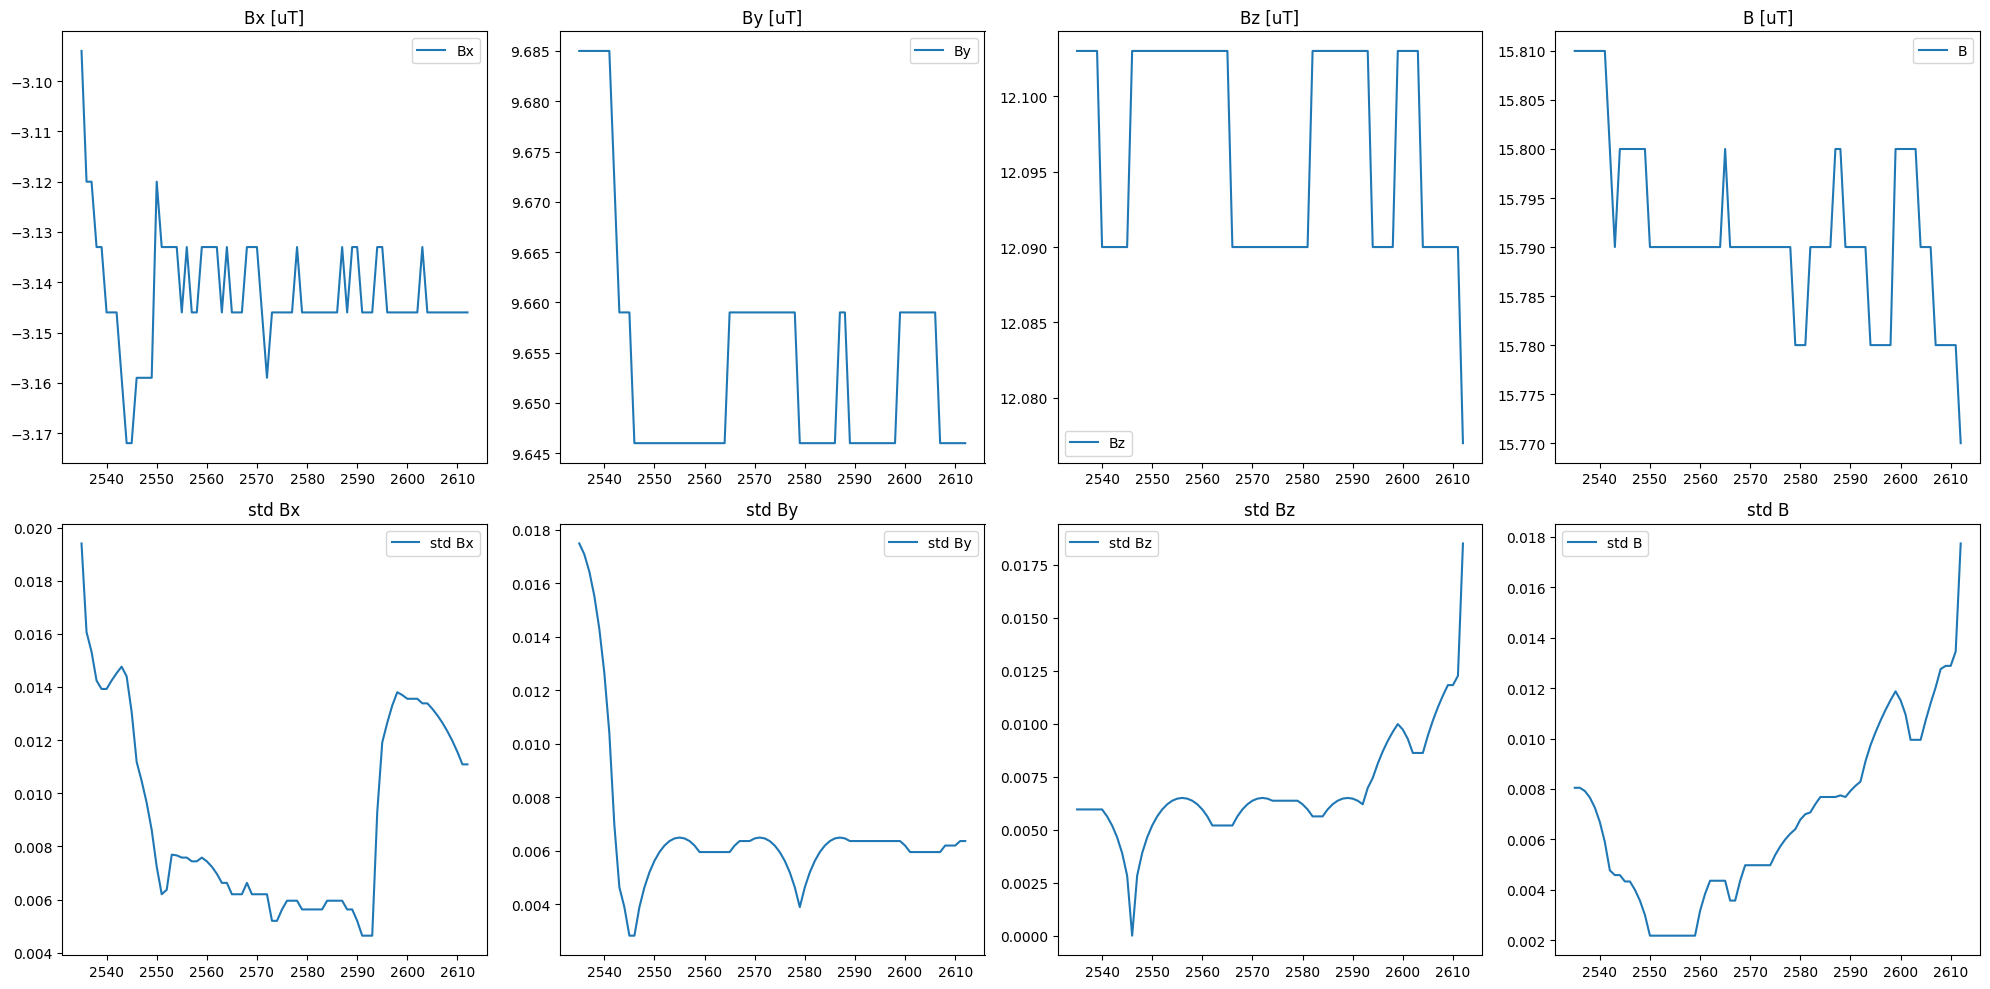

17


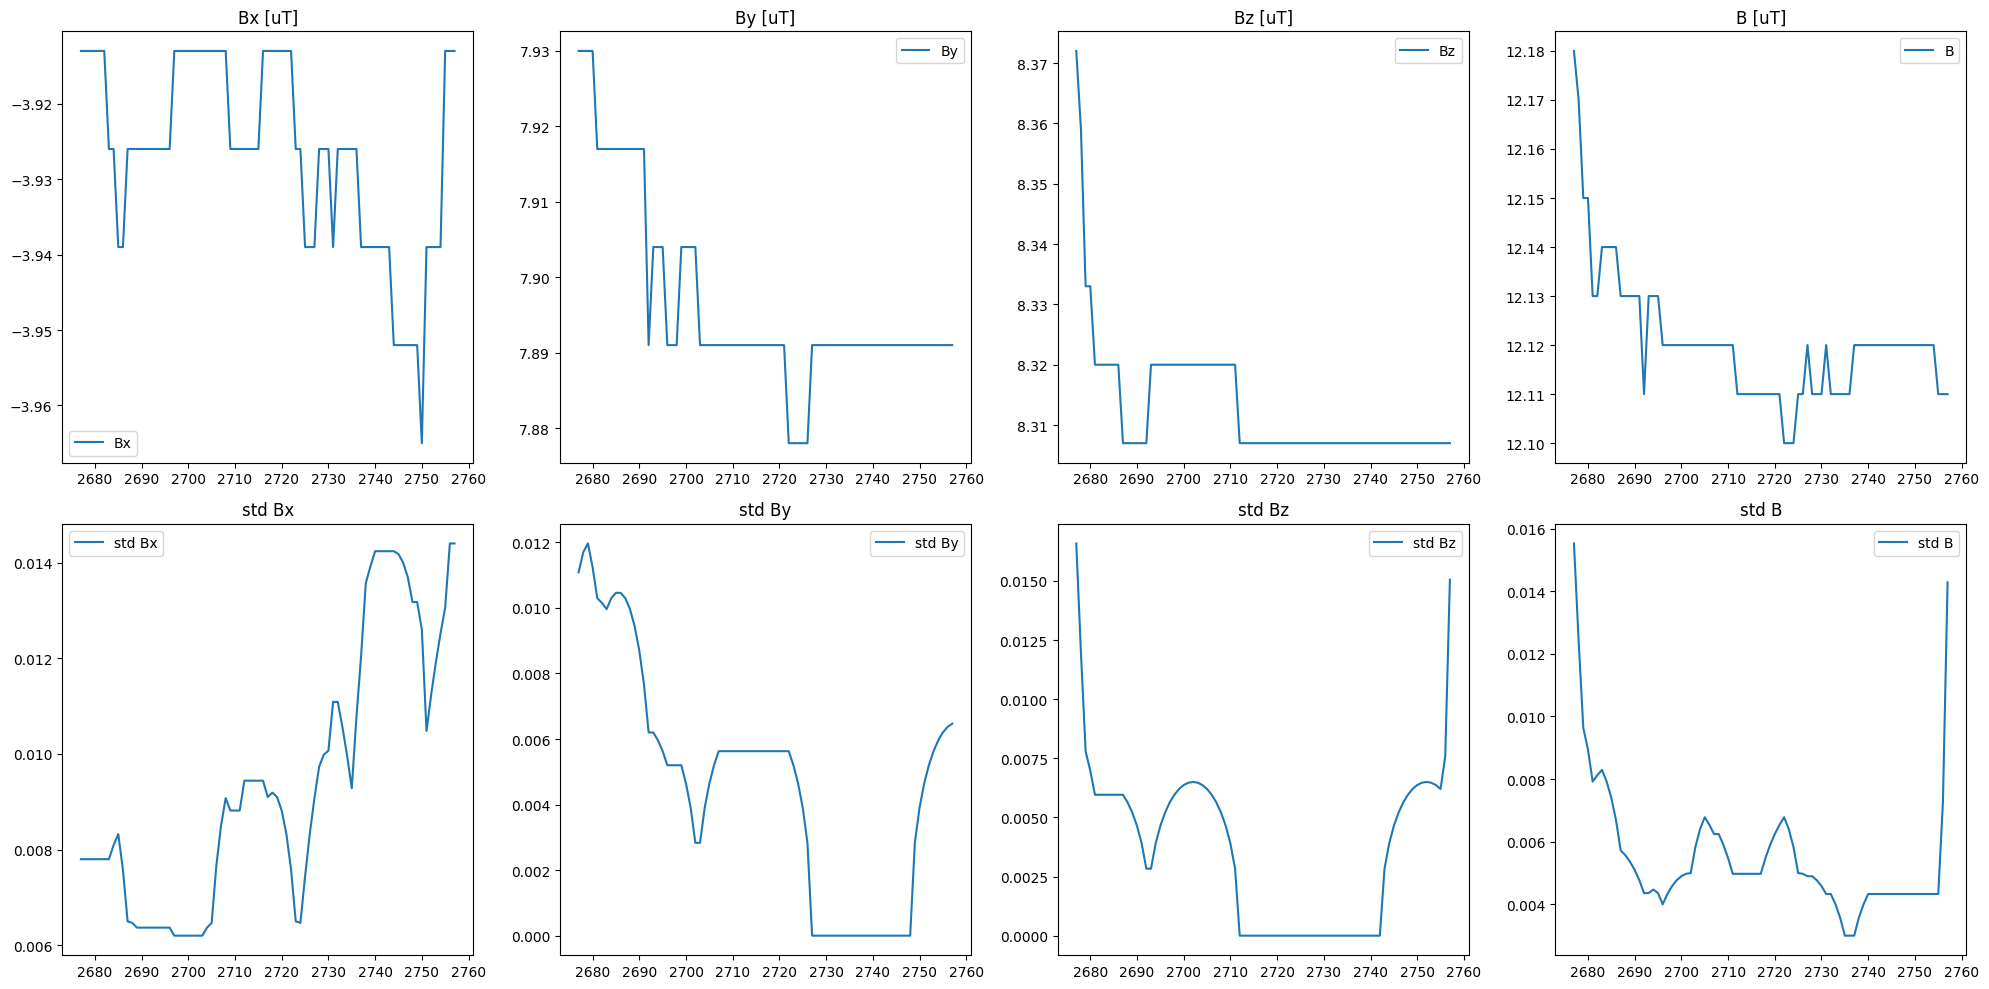

18


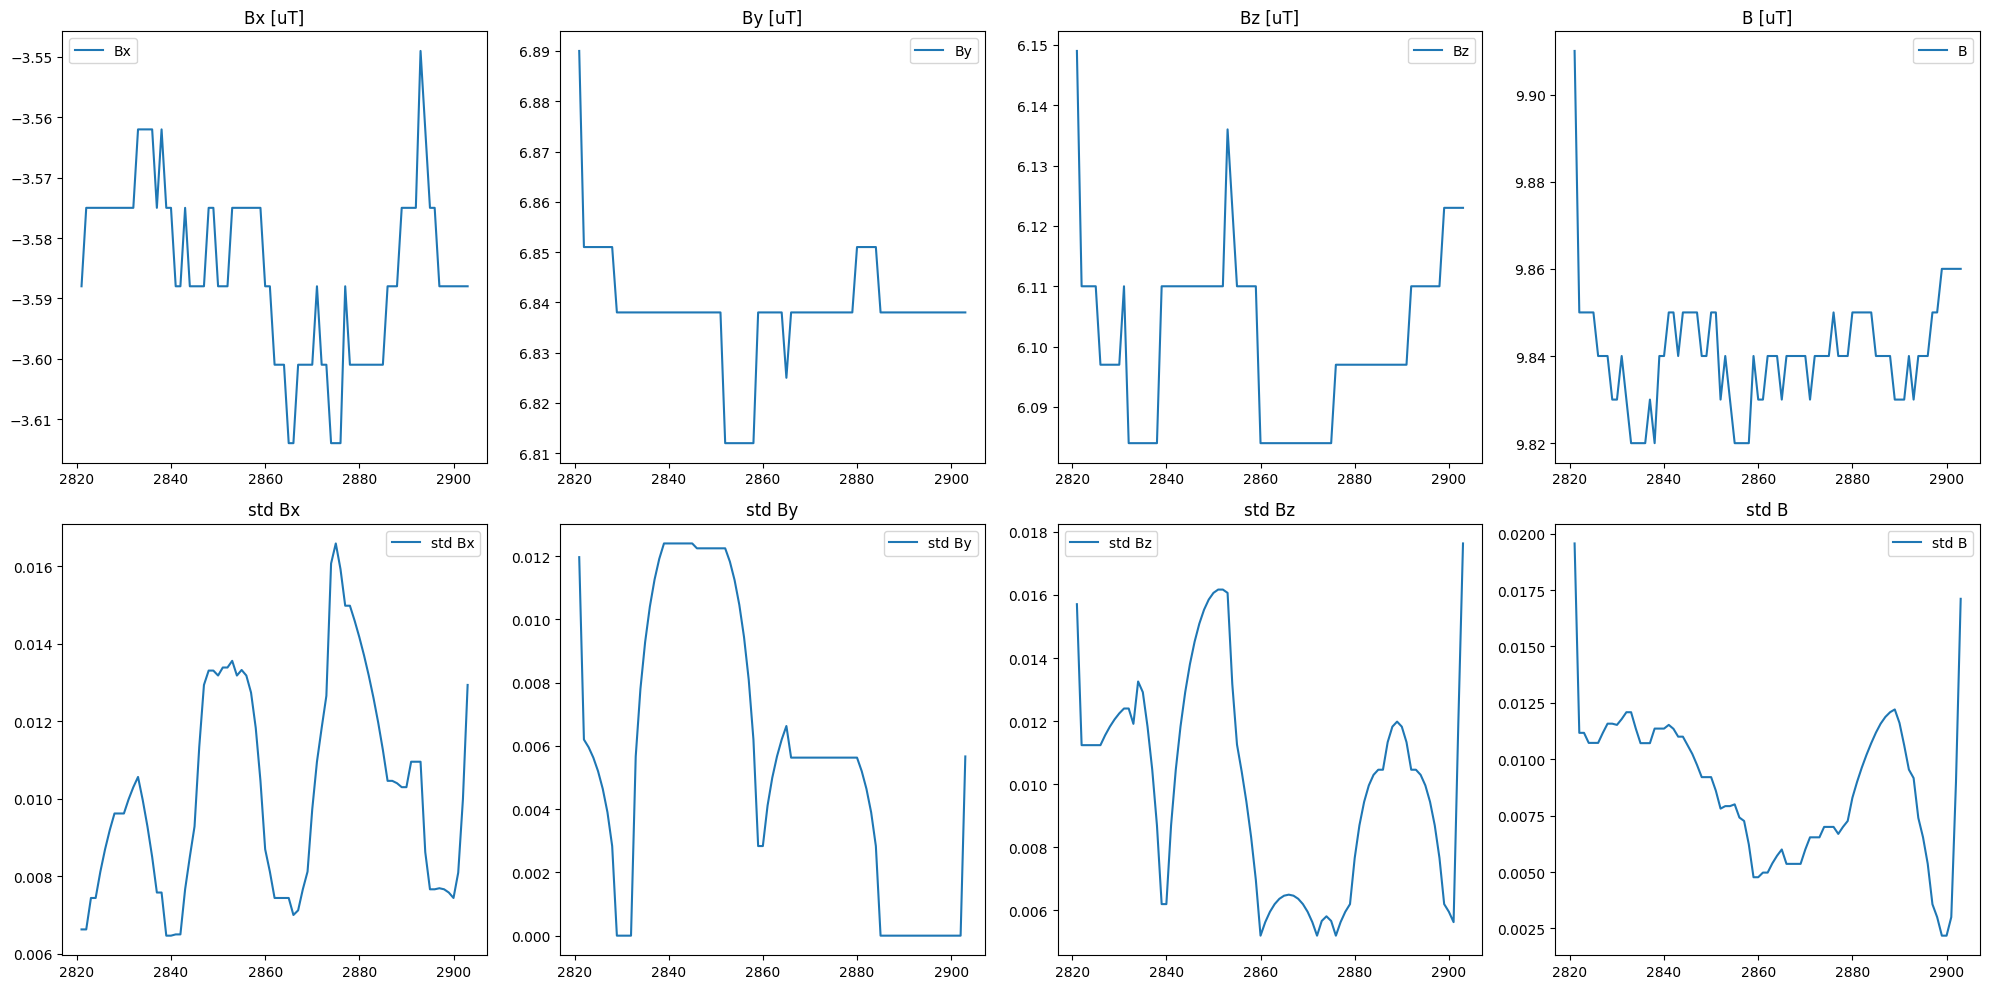

19


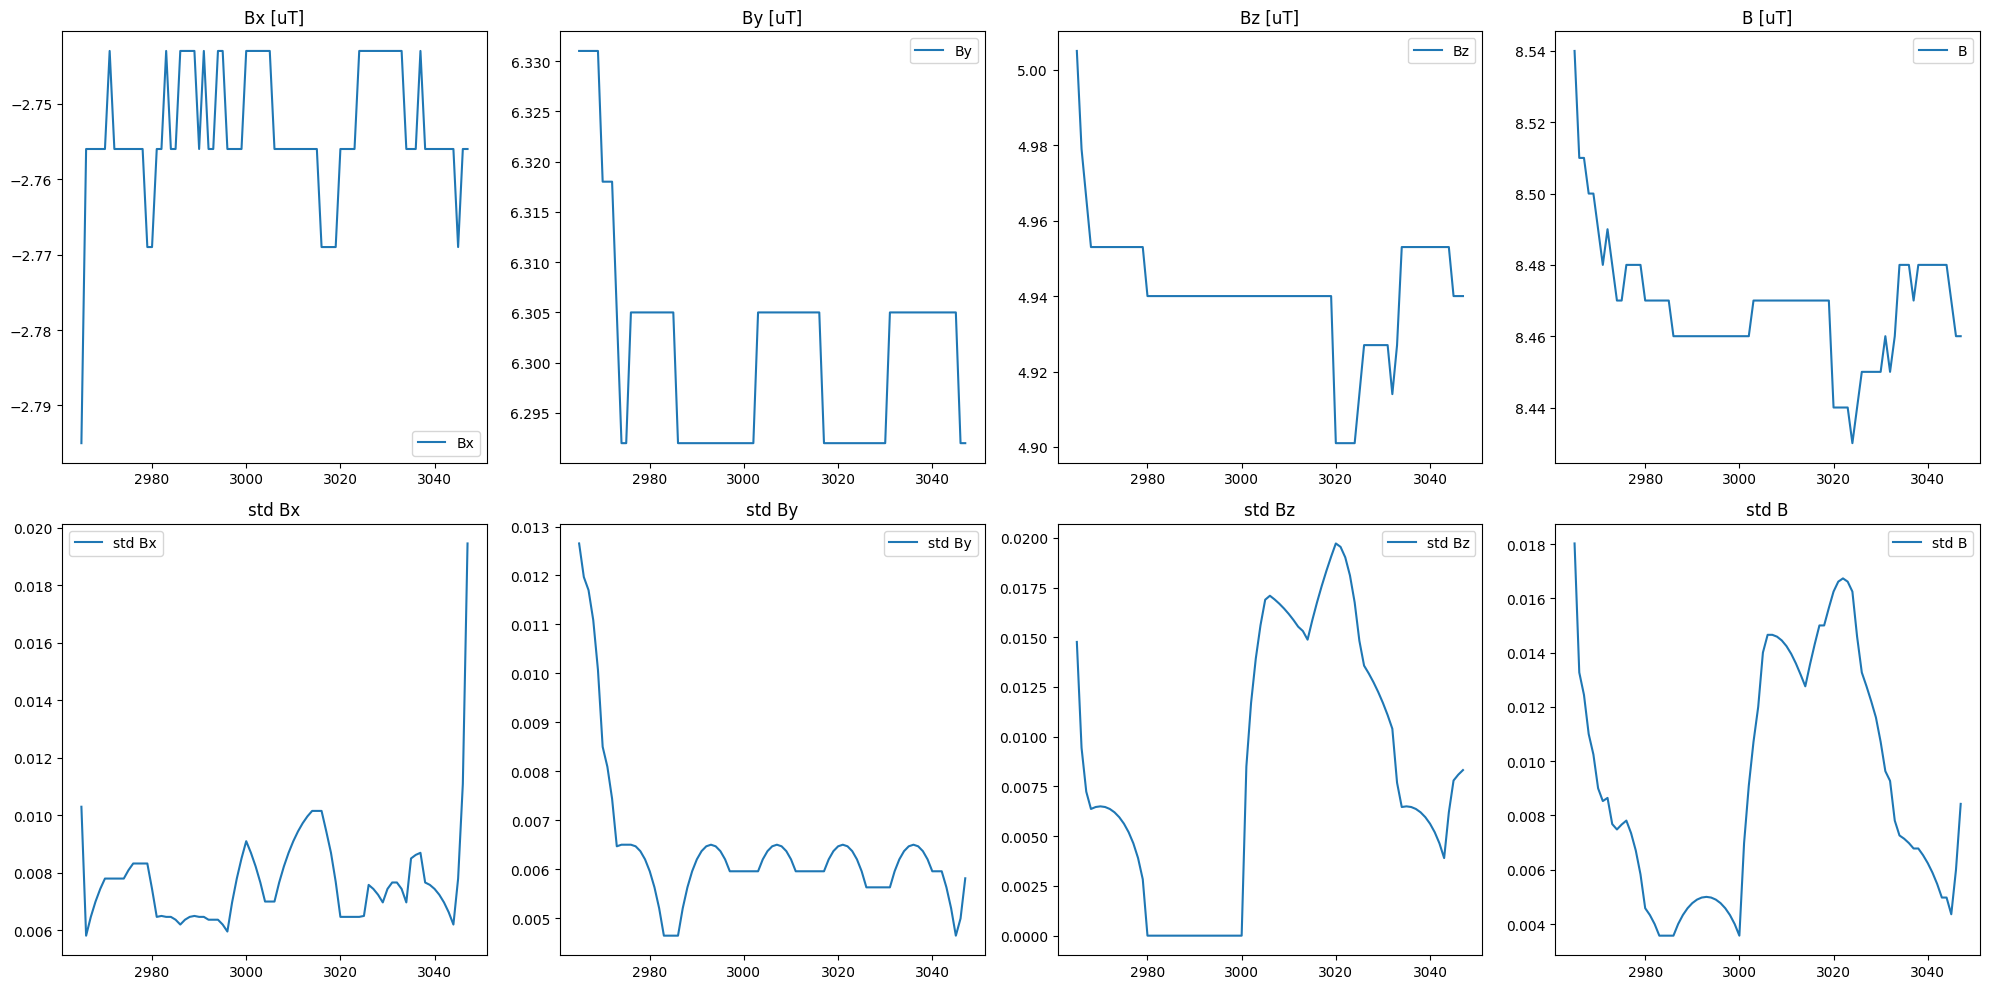

20


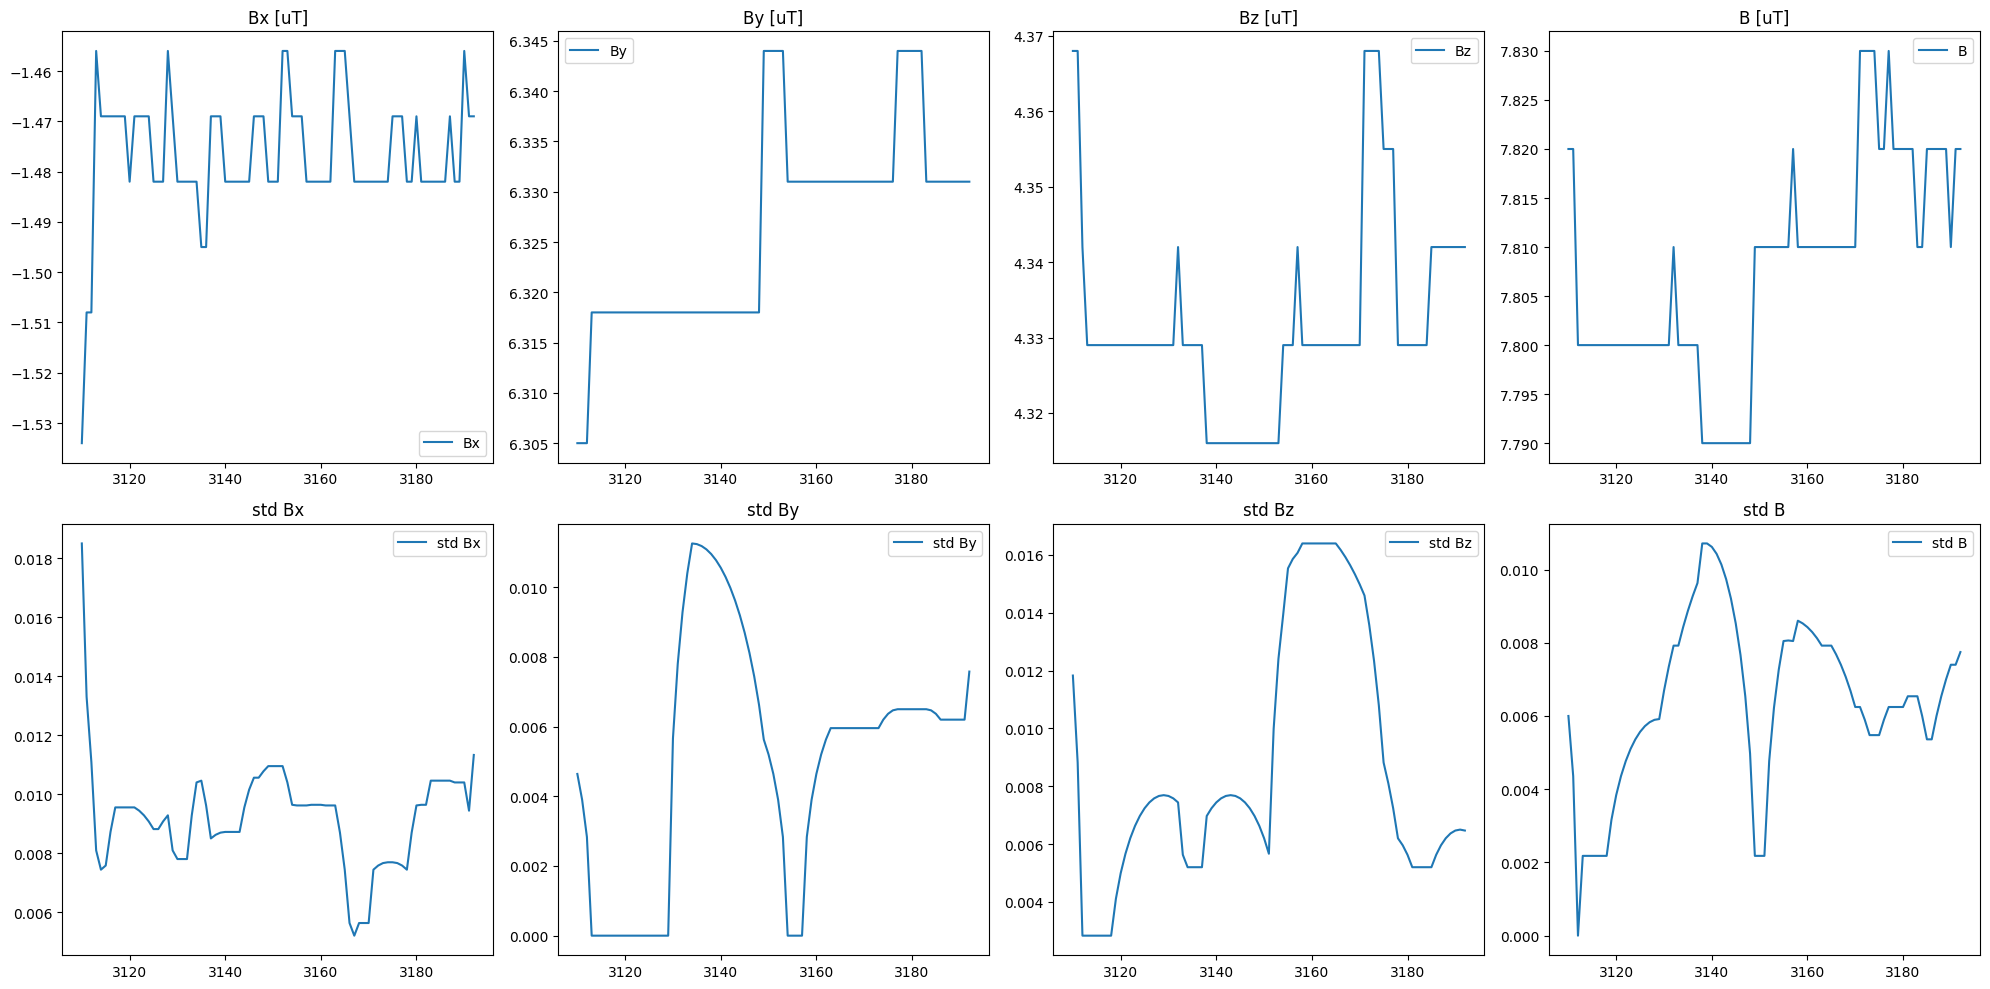

21


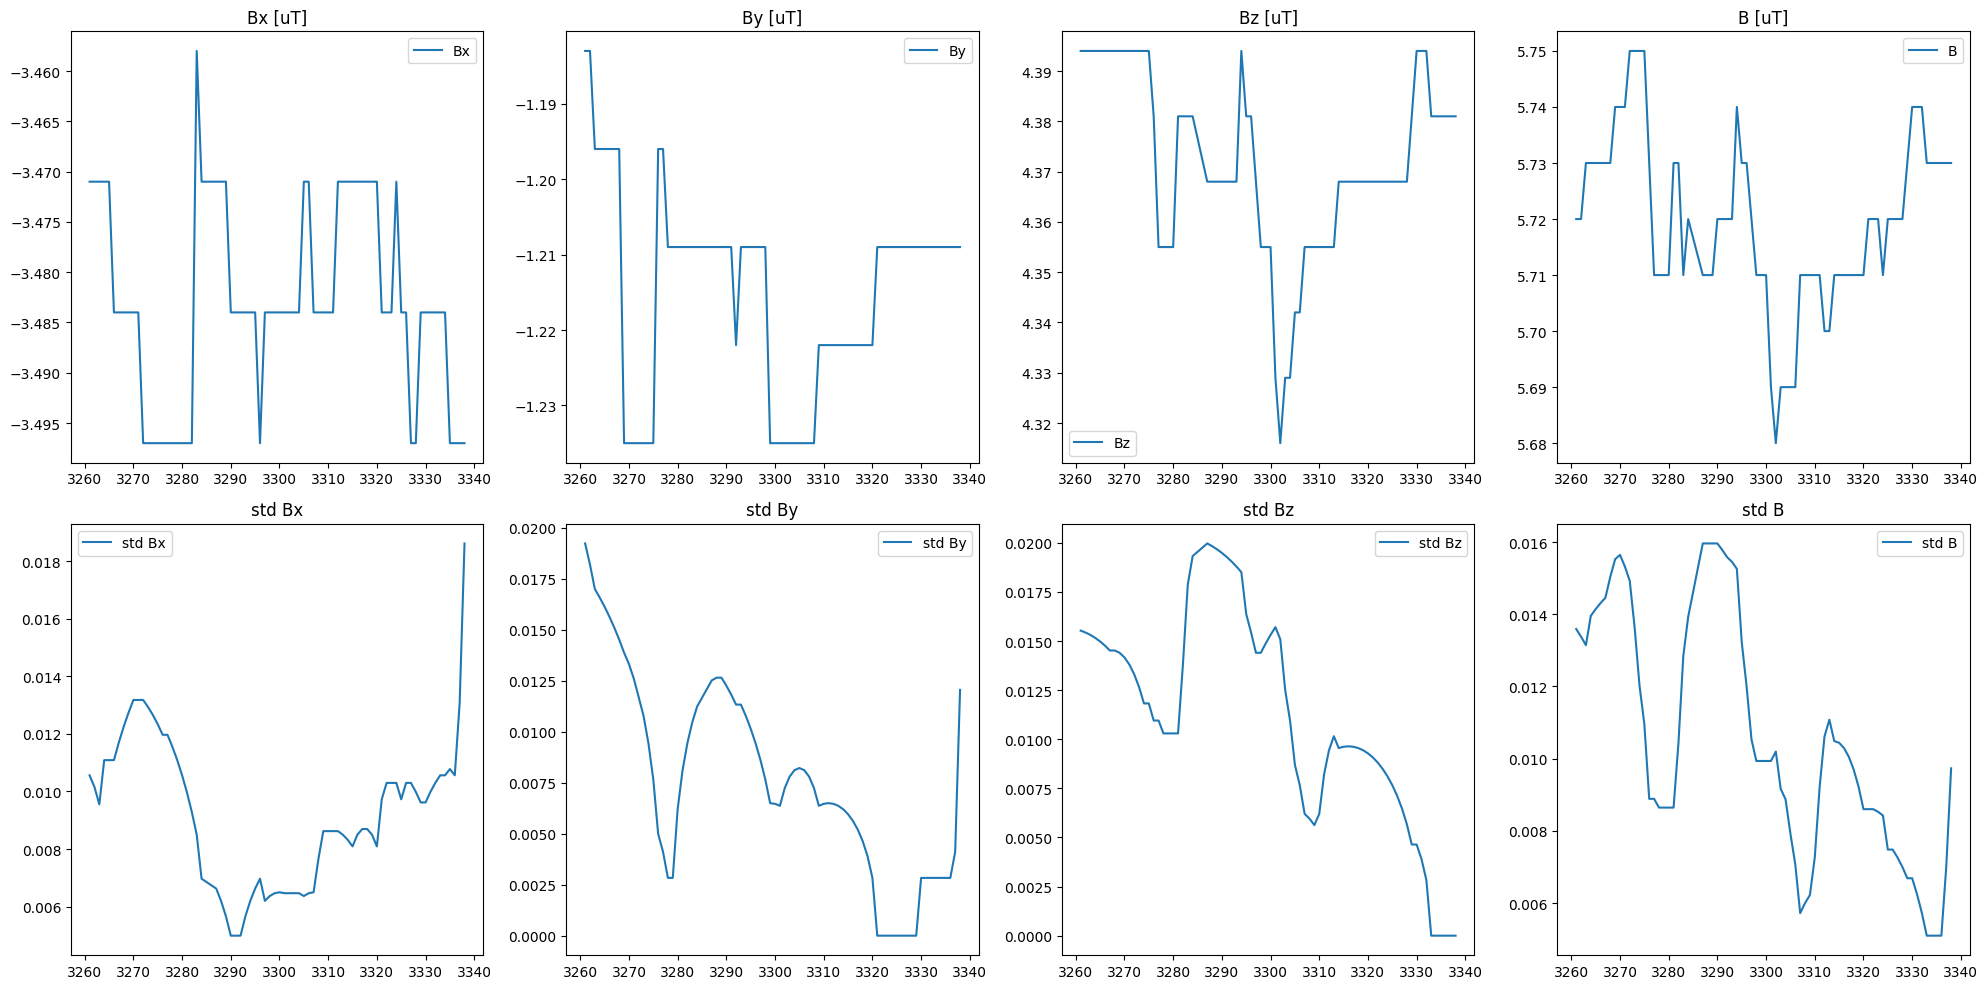

22


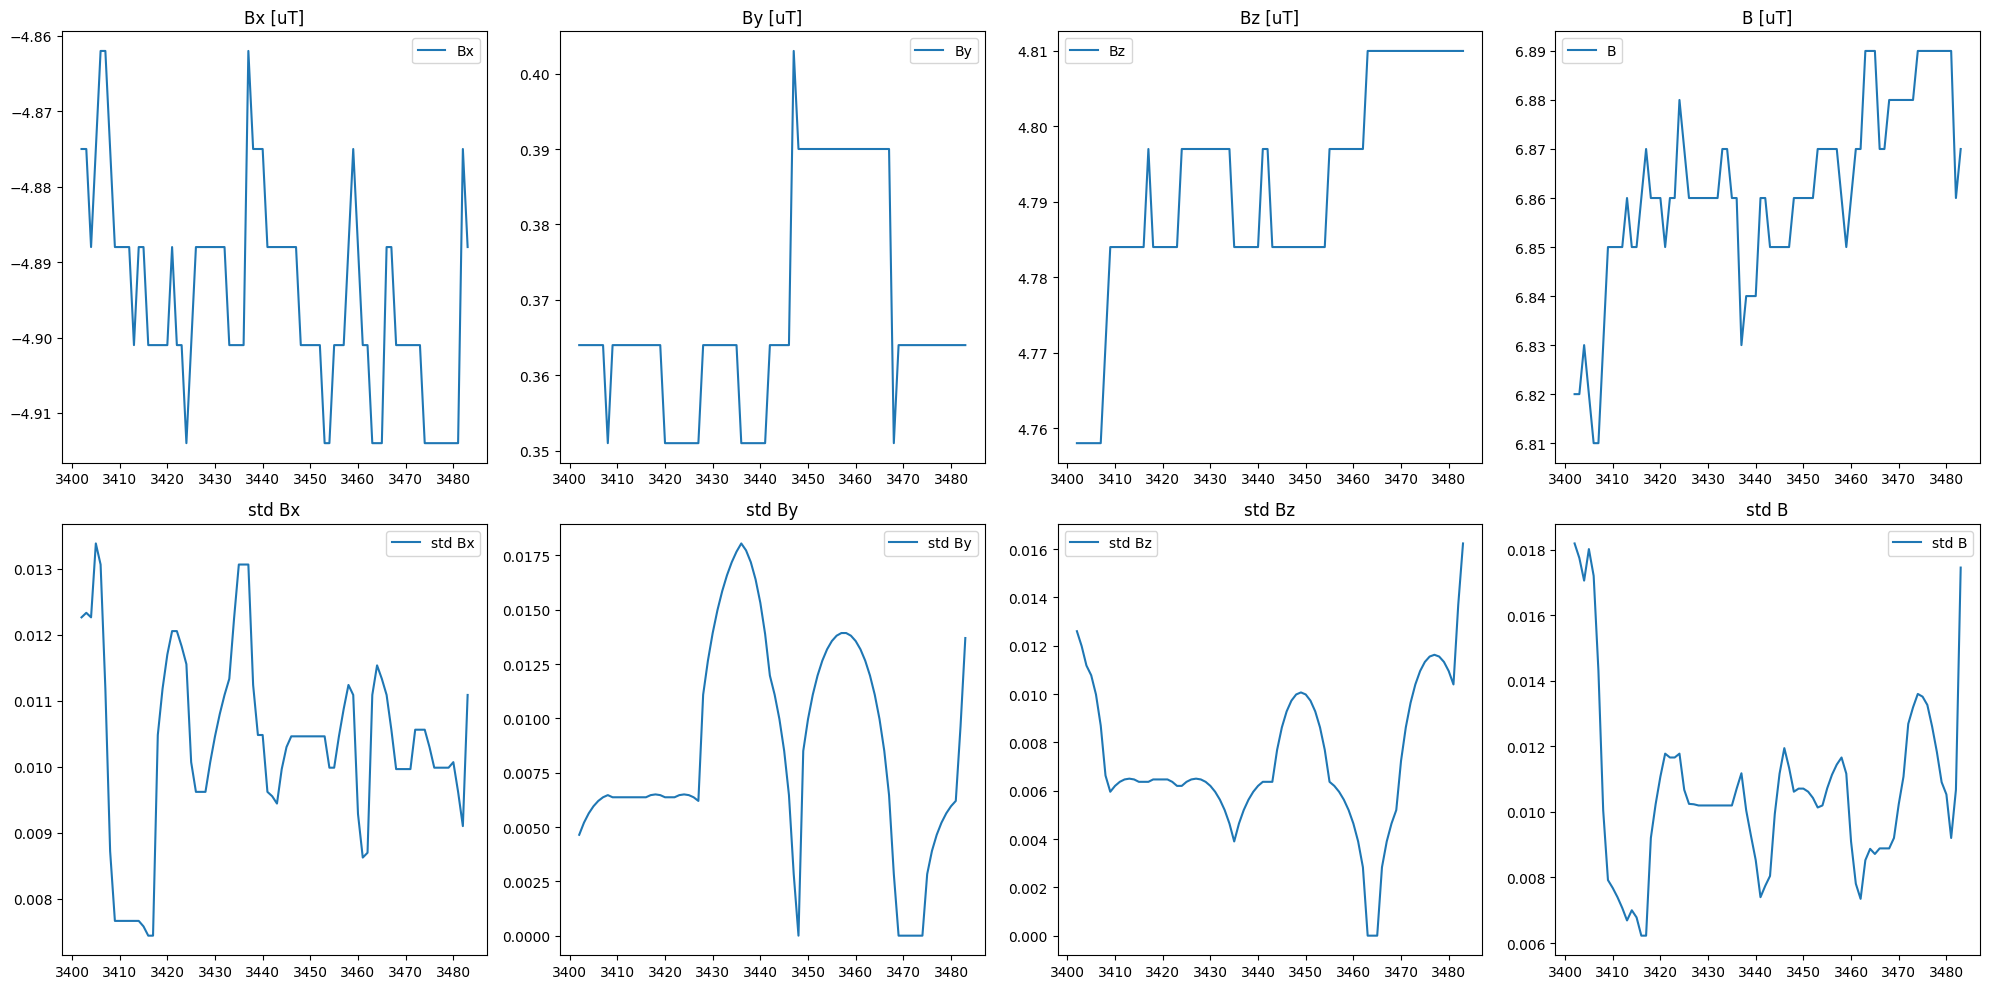

23


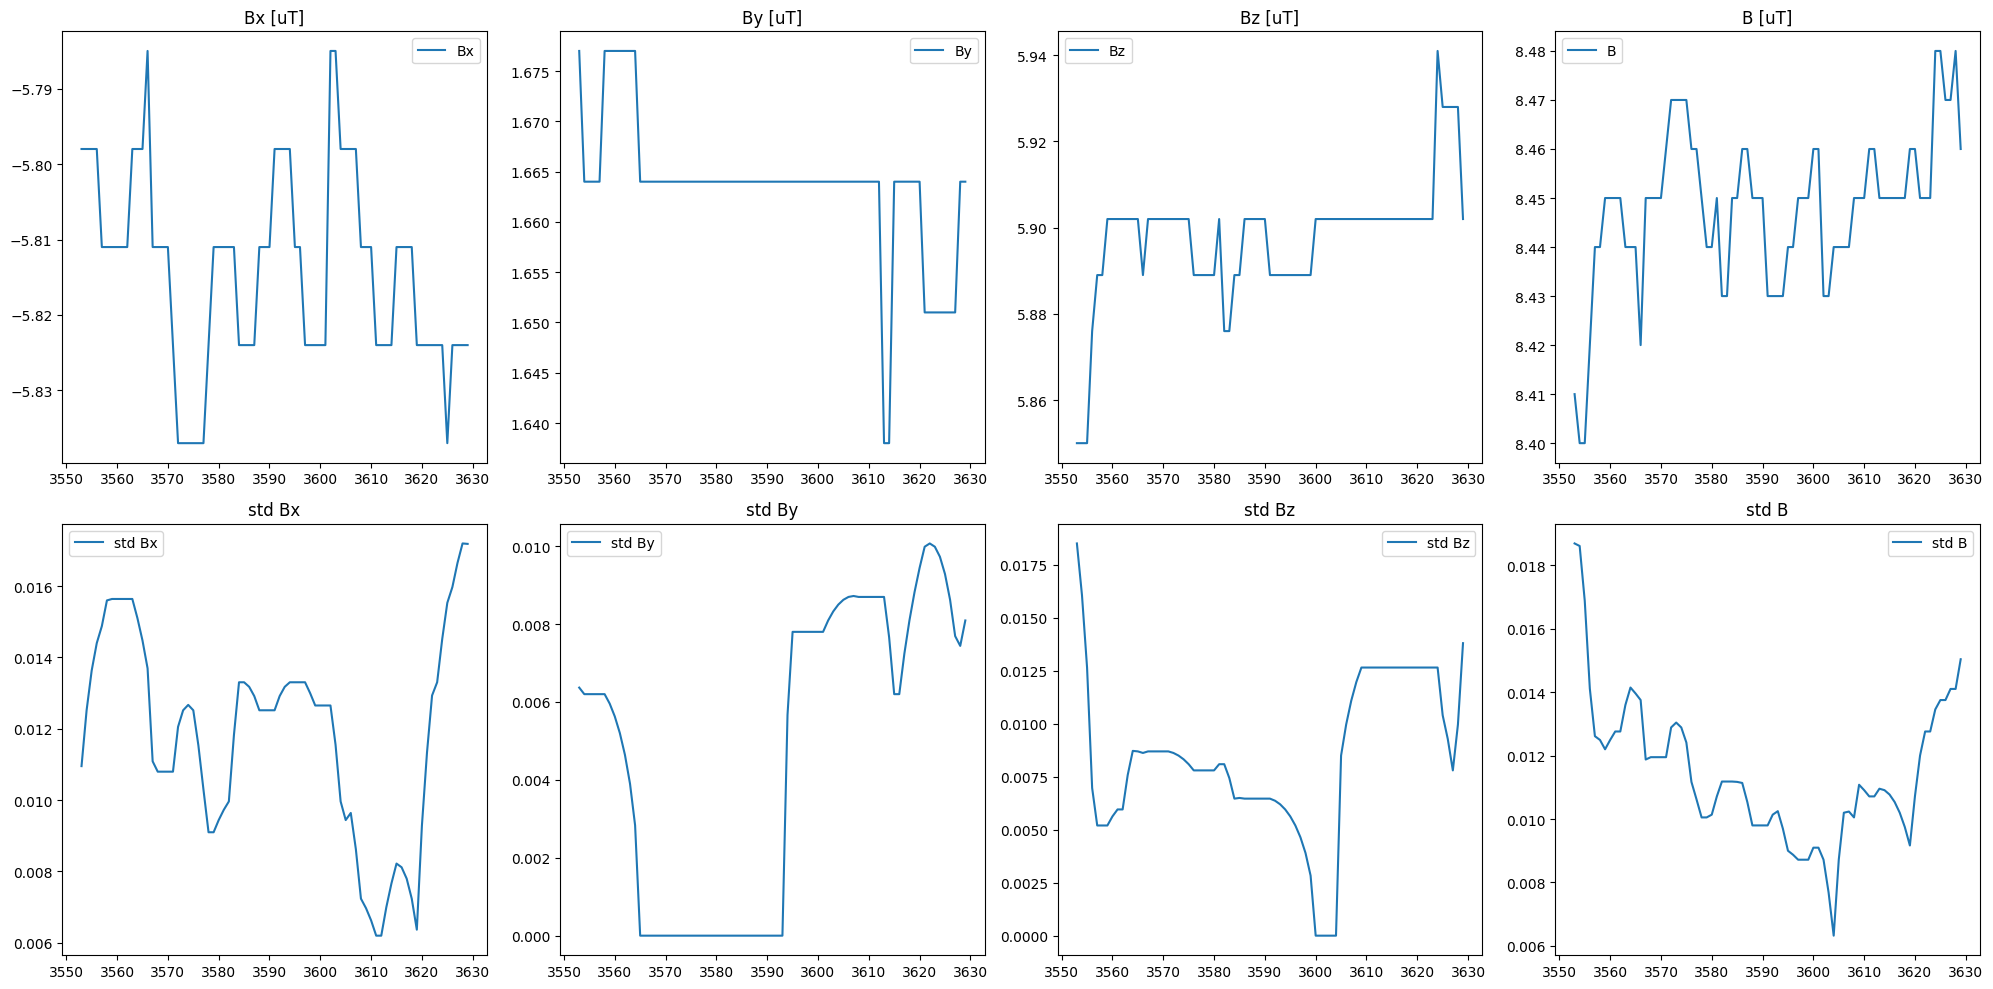

24


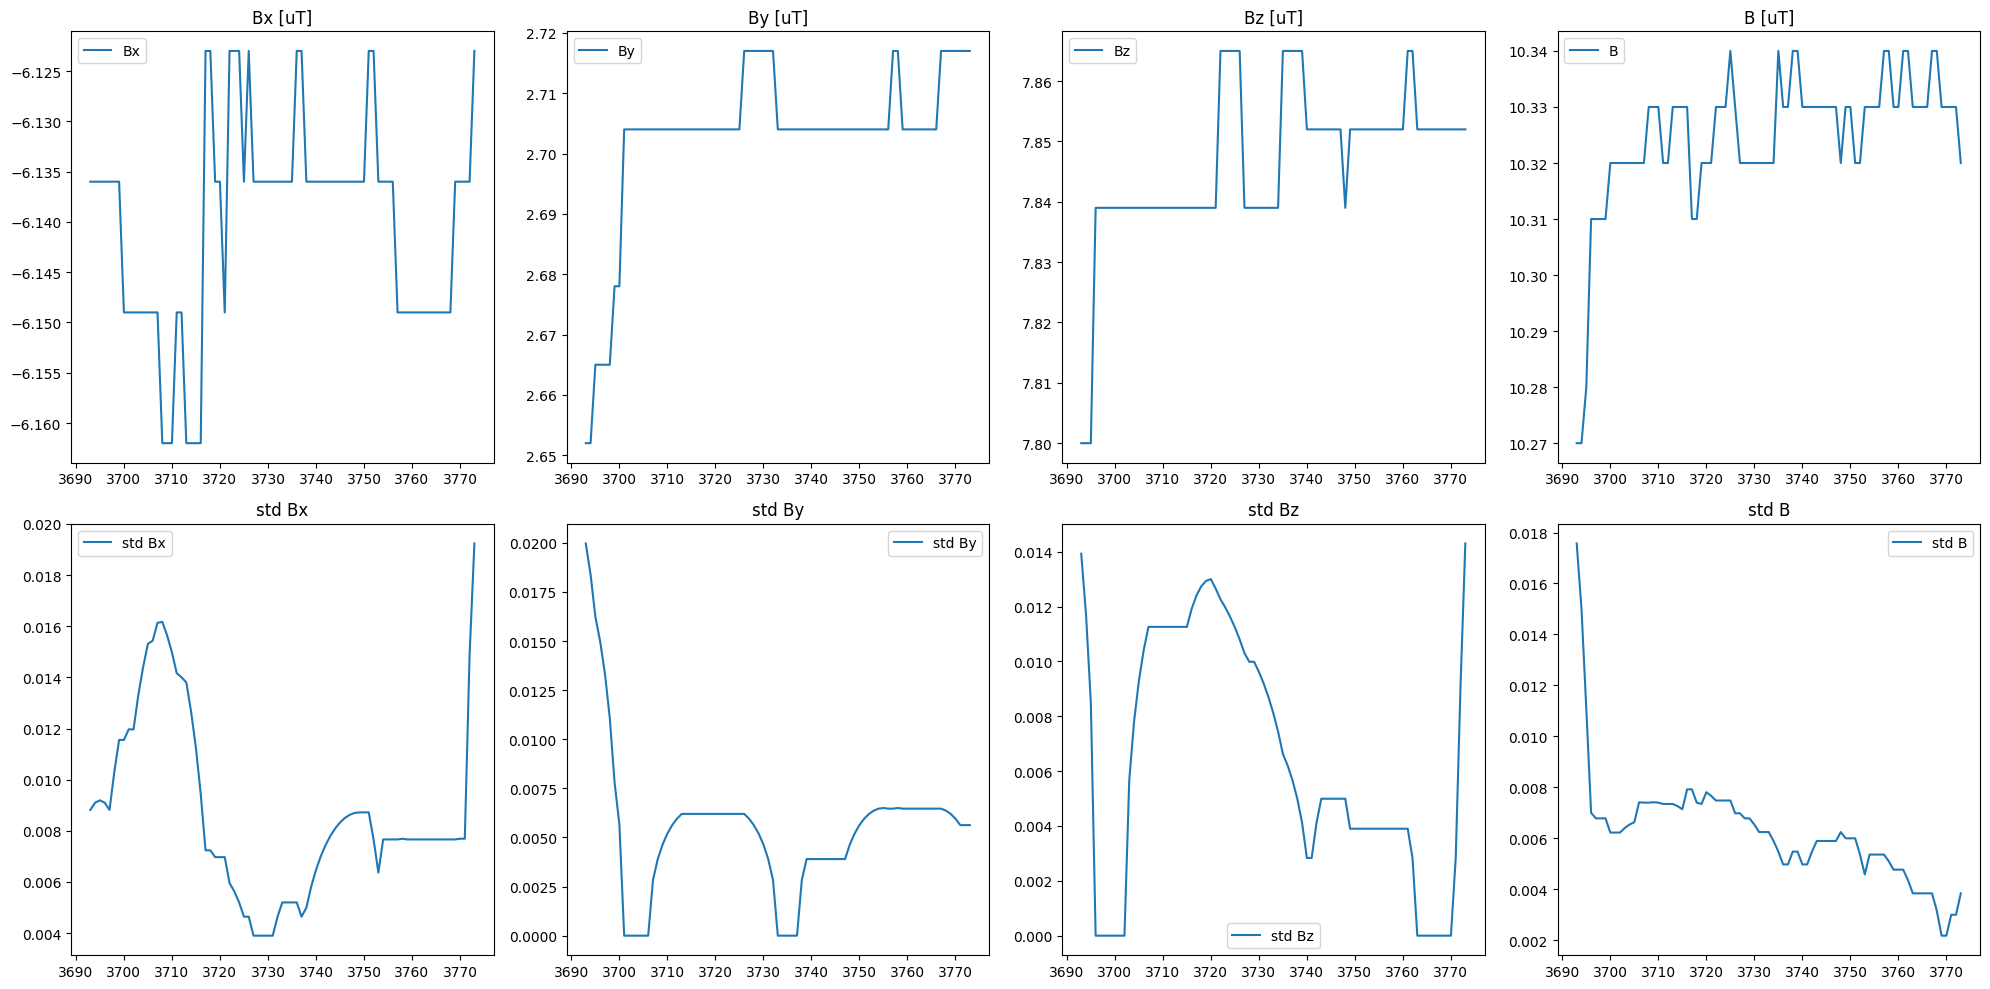

25


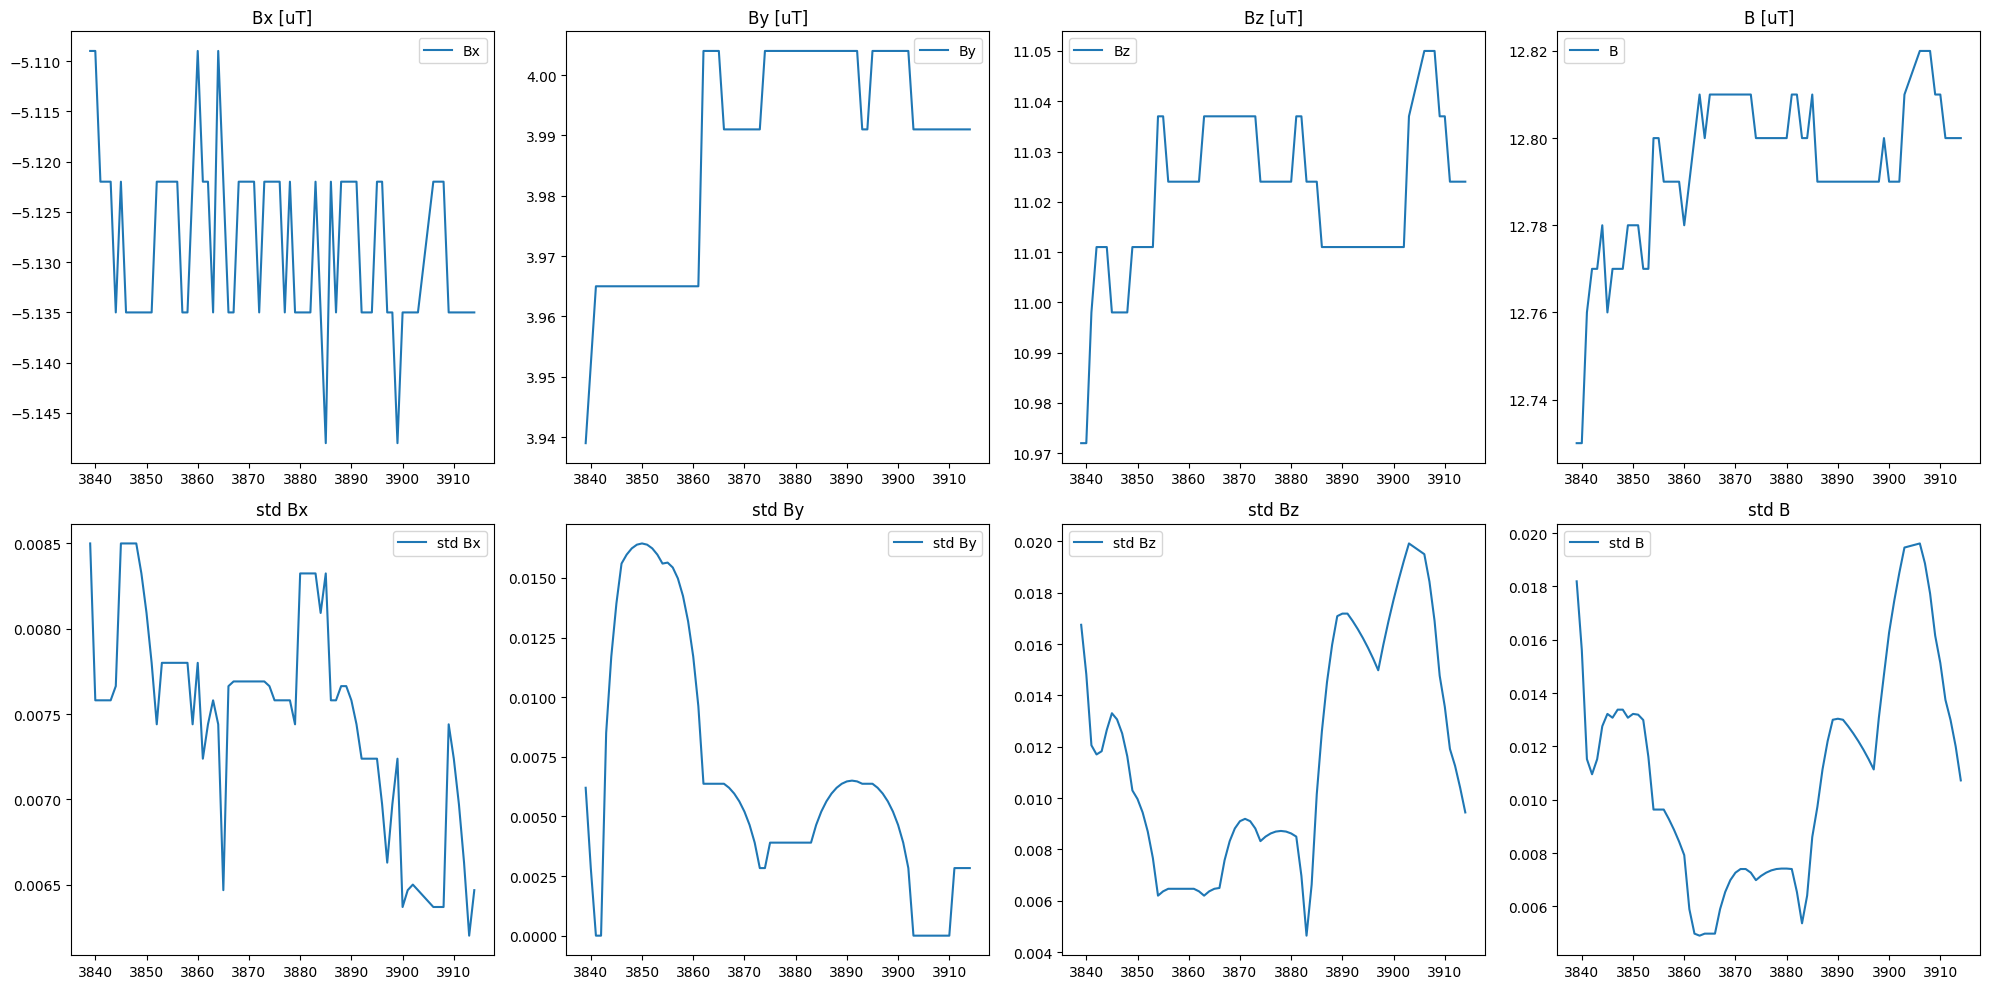

26


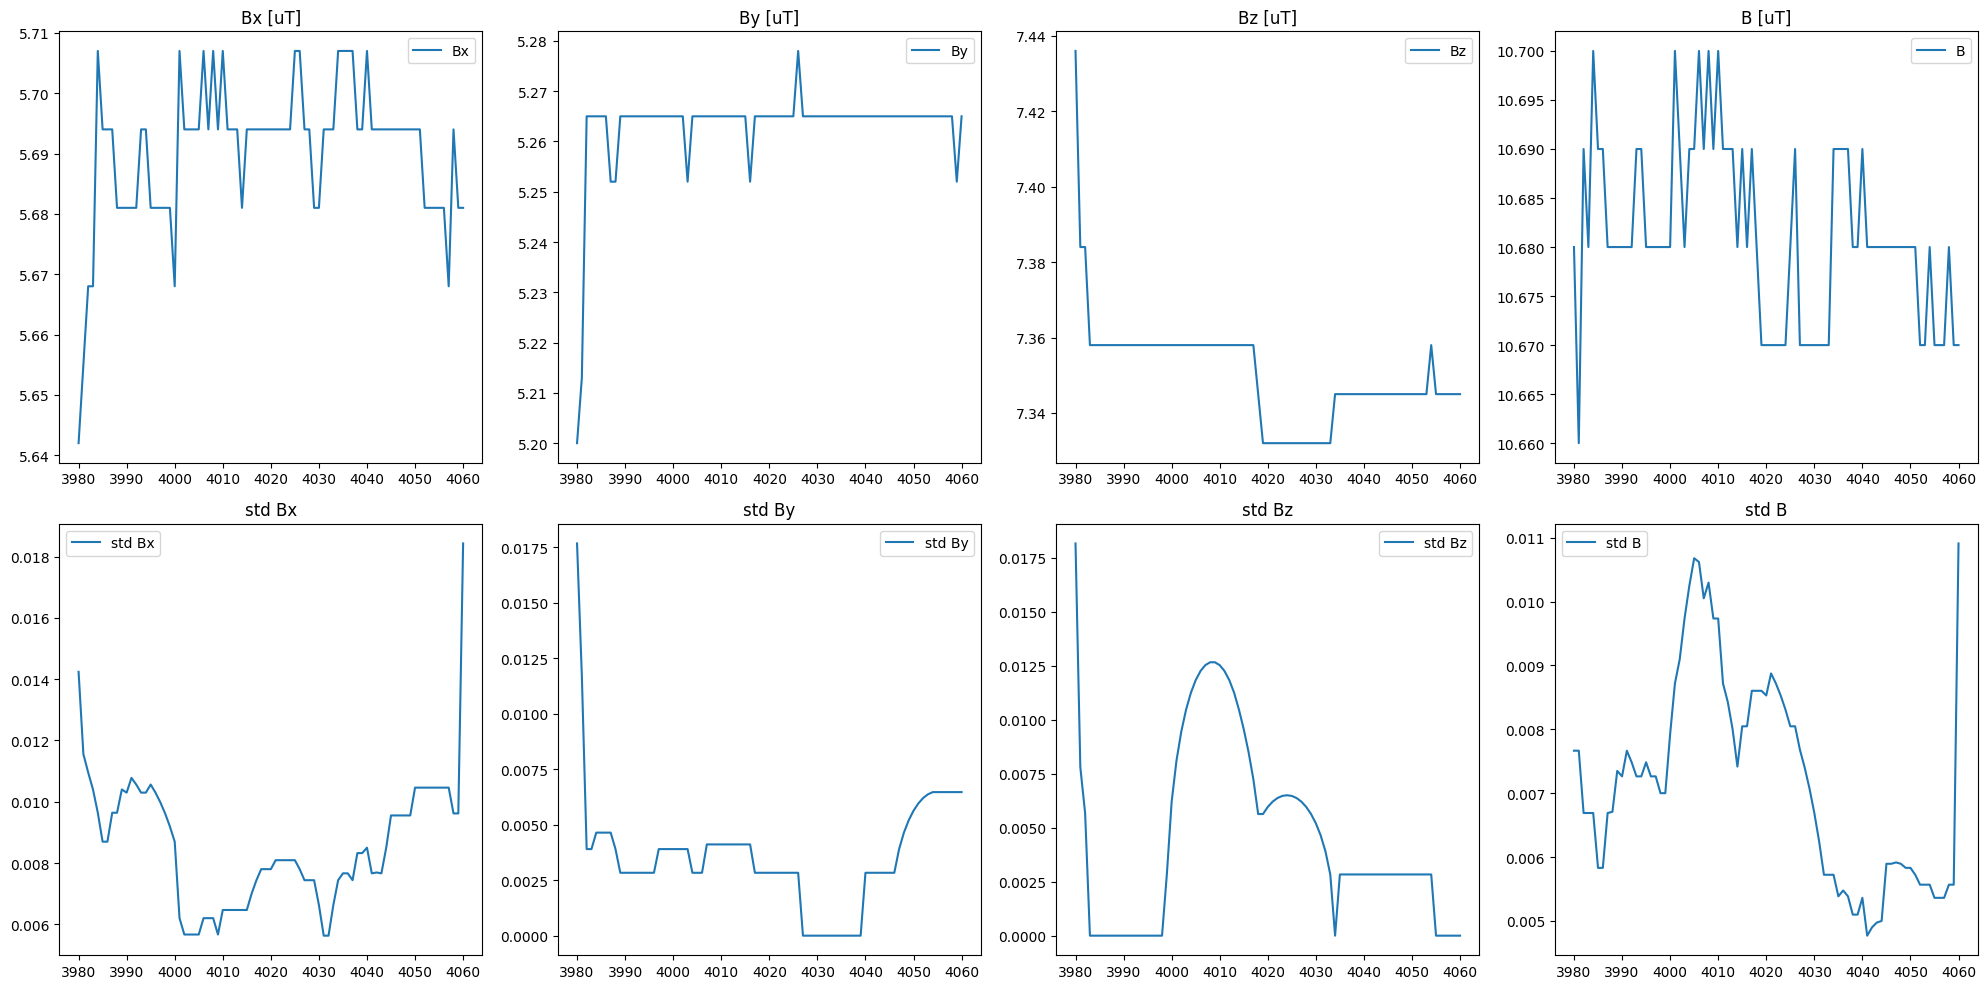

27


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fc17ab6c4f0>>
Traceback (most recent call last):
  File "/home/lbz/miniconda3/envs/jax/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fc17ab6c4f0>>
Traceback (most recent call last):
  File "/home/lbz/miniconda3/envs/jax/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fc17ab6c4f0>>
Traceback (most recent call last):
  File "/home/lbz/miniconda3/envs/jax/lib/python3.10/site-packages/ipykernel/ipkernel.py", 

KeyboardInterrupt: 

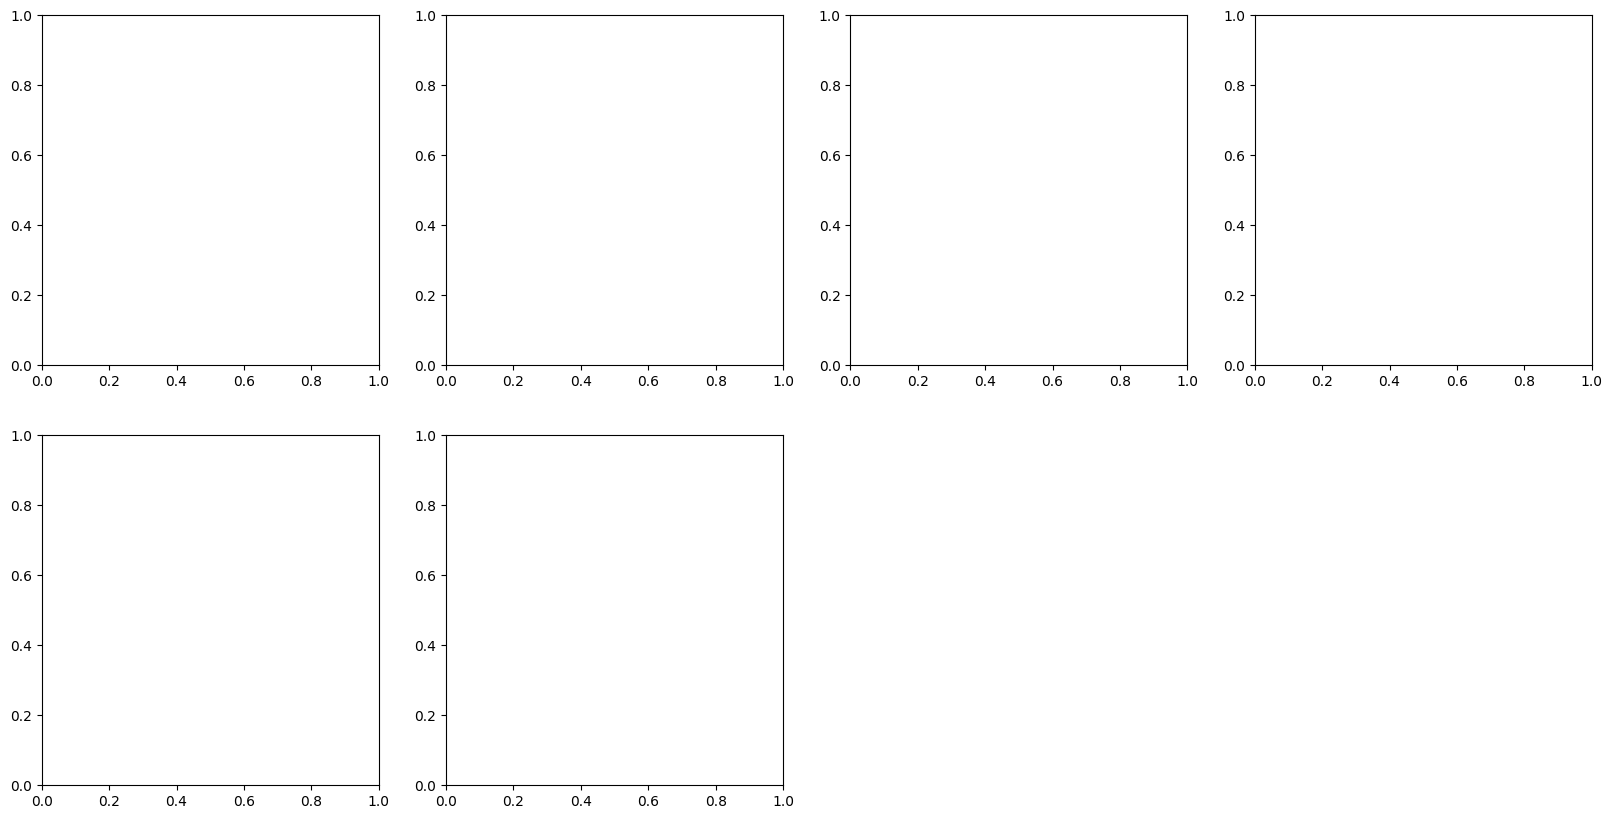

In [8]:
for i in range(len(steps)):
    sub = np.array(steps[i])
    print(i)
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
    
    ax = axes[0,0]
    ax.plot(sub[:,0], sub[:,1], label='Bx')
    ax.set_title(f"Bx [uT]")
    ax.legend()
    
    ax = axes[0,1]
    ax.plot(sub[:,0], sub[:,2], label='By')
    ax.set_title(f"By [uT]")
    ax.legend()
    
    ax = axes[0,2]
    ax.plot(sub[:,0], sub[:,3], label='Bz')
    ax.set_title(f"Bz [uT]")
    ax.legend()
    
    ax = axes[0,3]
    ax.plot(sub[:,0], sub[:,4], label='B')
    ax.set_title(f"B [uT]")
    ax.legend()
    
    ax = axes[1,0]
    ax.plot(sub[:,0], sub[:,5], label='std Bx')
    ax.set_title(f"std Bx")
    ax.legend()
    
    ax = axes[1,1]
    ax.plot(sub[:,0], sub[:,6], label='std By')
    ax.set_title(f"std By")
    ax.legend()
    
    ax = axes[1,2]
    ax.plot(sub[:,0], sub[:,7], label='std Bz')
    ax.set_title(f"std Bz")
    ax.legend()
    
    ax = axes[1,3]
    ax.plot(sub[:,0], sub[:,8], label='std B')
    ax.set_title(f"std B")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [8]:
print(len(steps))

126


In [9]:
x1 = [-80, -80, -80, -80, -80, -40, -40, -40, -40, -40,   0,   0,   0,   0,   0,  40,  40,  40,  40,  40,  80,  80,  80,  80,  80]
y1 = [-80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80]
z1 = [-80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80, -80]

x2 = [ 80,  80,  80,  80,  80,  40,  40,  40,  40,  40,   0,   0,   0,   0,   0, -40, -40, -40, -40, -40, -80, -80, -80, -80, -80]
y2 = [ 80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80]
z2 = [-40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40, -40]

x3 = [-80, -80, -80, -80, -80, -40, -40, -40, -40, -40,   0,   0,   0,   0,   0,  40,  40,  40,  40,  40,  80,  80,  80,  80,  80]
y3 = [-80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80]
z3 = [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0]

x4 = [ 80,  80,  80,  80,  80,  40,  40,  40,  40,  40,   0,   0,   0,   0,   0, -40, -40, -40, -40, -40, -80, -80, -80, -80, -80]
y4 = [ 80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80]
z4 = [ 40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40,  40]

x5 = [-80, -80, -80, -80, -80, -40, -40, -40, -40, -40,   0,   0,   0,   0,   0,  40,  40,  40,  40,  40,  80,  80,  80,  80,  80]
y5 = [-80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80,  80,  40,   0, -40, -80, -80, -40,   0,  40,  80]
z5 = [ 80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80,  80]

x = x1 + x2 + x3 + x4 + x5
y = y1 + y2 + y3 + y4 + y5
z = z1 + z2 + z3 + z4 + z5

test_idx = [31, 32, 33, 36, 37, 38, 41, 42, 43, 66, 67, 68, 61, 62, 63, 56, 57, 58, 81, 82, 83, 86, 87, 88, 91, 92, 93]

train_set = []
test_set = []
total_set = []
for i in range(1,len(steps)):
    sub = np.array(steps[i])
    #print(i)
    #print(sub.shape)
    Bx = sub[10:,1].mean()
    By = sub[10:,2].mean()
    Bz = sub[10:,3].mean()
    B  = np.sqrt(Bx**2+By**2+Bz**2)
    ax = x[i-1]
    ay = y[i-1]
    az = z[i-1]
    if i-1 in test_idx:
        test_set.append([B, By, -Bz, Bx, ax, ay, az])
        print(ax, ay, az, By, -Bz, Bx)
    else:
        train_set.append([B, By, -Bz, Bx, ax, ay, az])
    total_set.append([B, By, -Bz, Bx, ax, ay, az])

40 -40 -40 5.069306666666667 -5.4990000000000006 3.35608
40 0 -40 5.520124999999999 -5.927458333333333 2.60975
40 40 -40 6.615968253968255 -7.103571428571425 3.1082380952380957
0 40 -40 7.404583333333335 -7.878902777777778 4.554694444444444
0 0 -40 6.730343750000001 -5.9109375 4.007859375
0 -40 -40 6.968838709677421 -4.778338709677419 4.669096774193547
-40 -40 -40 6.727324324324324 -3.3750810810810807 7.046527027027027
-40 0 -40 5.841875 -5.351328125 6.432968750000001
-40 40 -40 5.837366197183098 -8.246577464788734 7.189549295774648
-40 40 0 3.5493611111111107 -6.859305555555554 7.6667499999999995
-40 0 0 3.7413287671232878 -5.29278082191781 6.857232876712328
-40 -40 0 4.64411267605634 -4.485732394366197 7.358
0 -40 0 6.07080303030303 -5.735954545454546 6.264227272727272
0 0 0 5.774527777777777 -5.777958333333334 5.743833333333334
0 40 0 6.419802816901408 -6.481690140845072 6.413028169014085
40 40 0 6.94182191780822 -5.498643835616439 6.423958904109589
40 0 0 5.751333333333332 -5.67216

In [10]:
np.save('train_set.npy', np.array(train_set))
np.save('test_set.npy', np.array(test_set))

In [11]:
total_set=np.array(total_set)

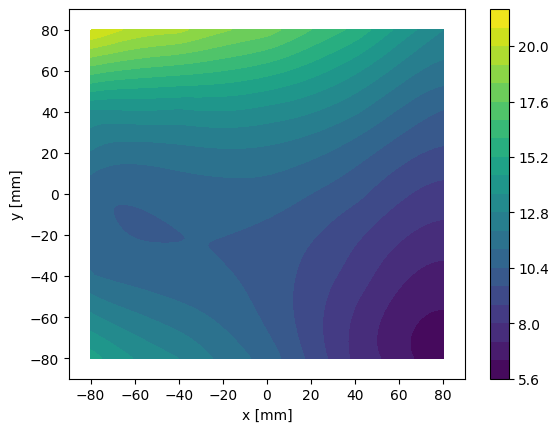

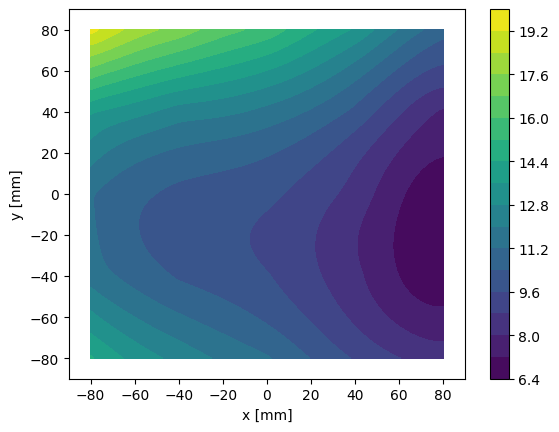

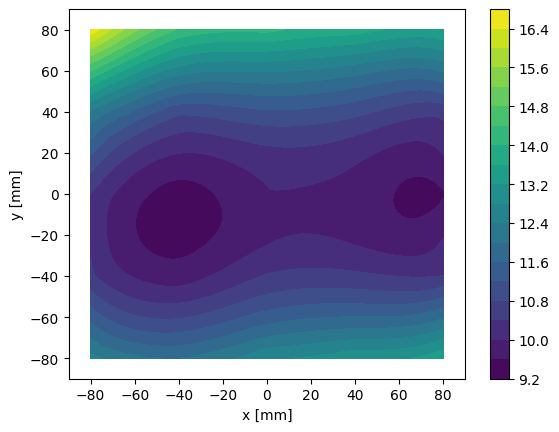

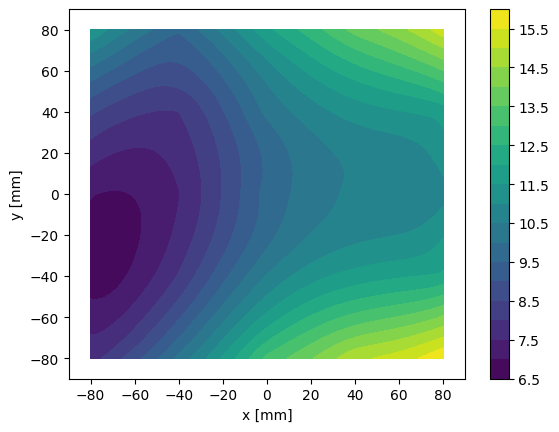

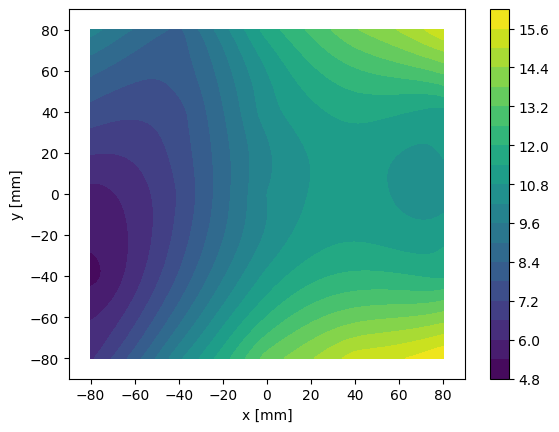

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
for i in range(5):
    B = total_set[25*i:25*i+25, 0]
    x = total_set[25*i:25*i+25, 4]
    y = total_set[25*i:25*i+25, 5]
    
    # 创建网格
    xi = np.linspace(min(x), max(x), 100)
    yi = np.linspace(min(y), max(y), 100)
    xi, yi = np.meshgrid(xi, yi)

    # 使用径向基函数插值
    rbf = Rbf(x, y, B, function='linear')
    zi = rbf(xi, yi)

    # 创建等高线图
    plt.contourf(xi, yi, zi, levels=20, cmap='viridis')
    plt.colorbar(label='')

    # 设置坐标轴标签
    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')

    # 设置坐标轴范围
    plt.xlim(min(x) - 10, max(x) + 10)
    plt.ylim(min(y) - 10, max(y) + 10)

    # 显示图形
    plt.show()

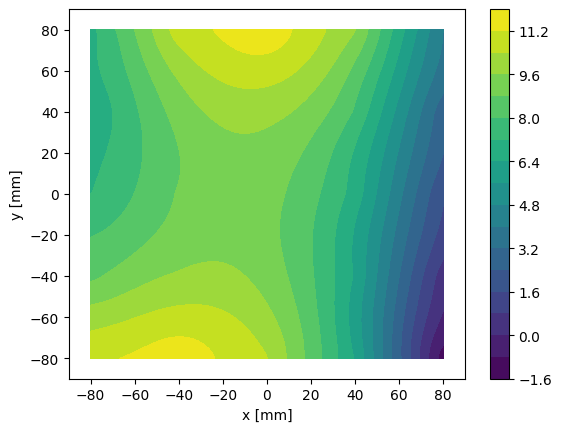

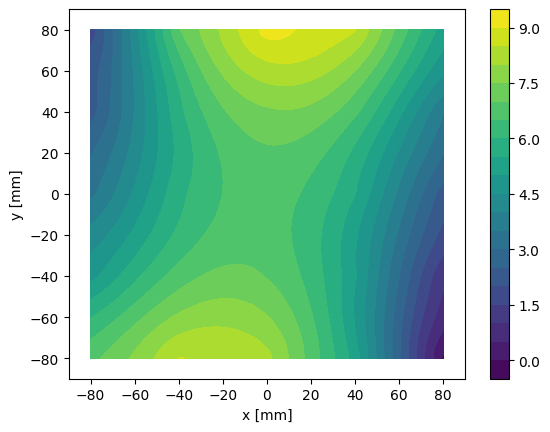

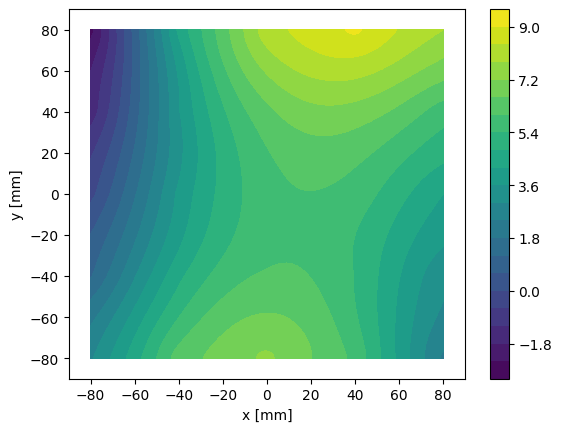

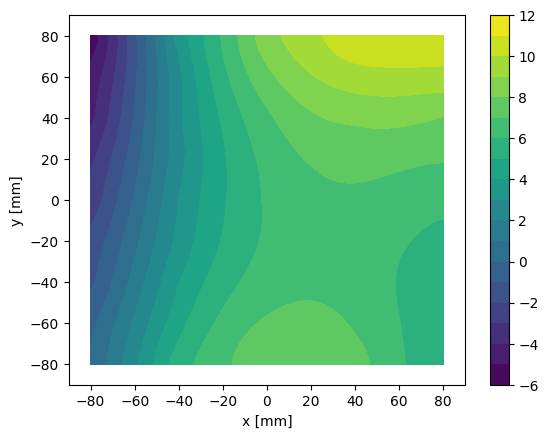

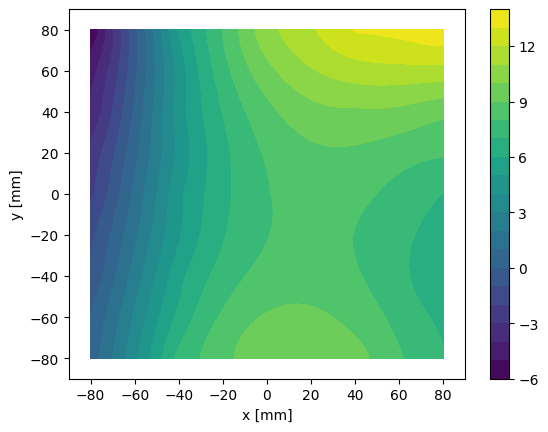

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
for i in range(5):
    B = total_set[25*i:25*i+25, 1]
    x = total_set[25*i:25*i+25, 4]
    y = total_set[25*i:25*i+25, 5]
    
    # 创建网格
    xi = np.linspace(min(x), max(x), 100)
    yi = np.linspace(min(y), max(y), 100)
    xi, yi = np.meshgrid(xi, yi)

    # 使用径向基函数插值
    rbf = Rbf(x, y, B, function='linear')
    zi = rbf(xi, yi)

    # 创建等高线图
    plt.contourf(xi, yi, zi, levels=20, cmap='viridis')
    plt.colorbar(label='')

    # 设置坐标轴标签
    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')

    # 设置坐标轴范围
    plt.xlim(min(x) - 10, max(x) + 10)
    plt.ylim(min(y) - 10, max(y) + 10)

    # 显示图形
    plt.show()

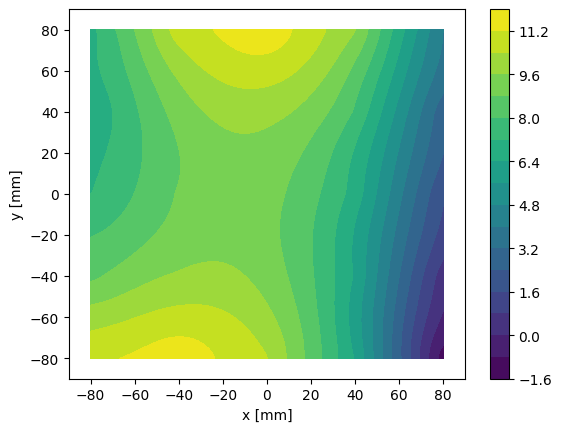

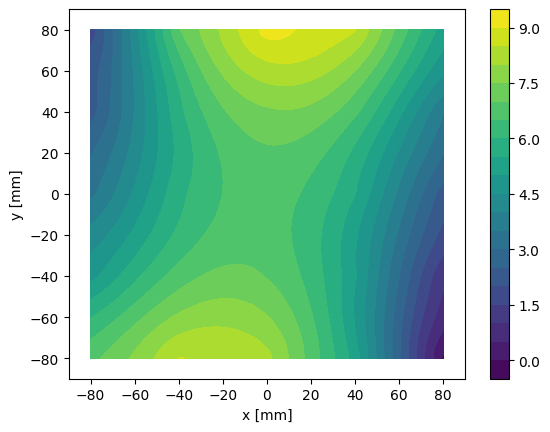

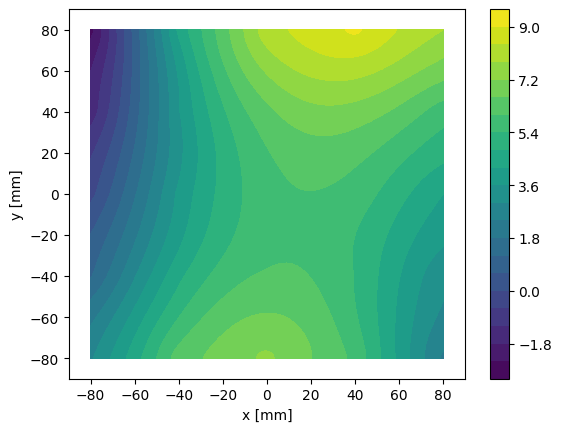

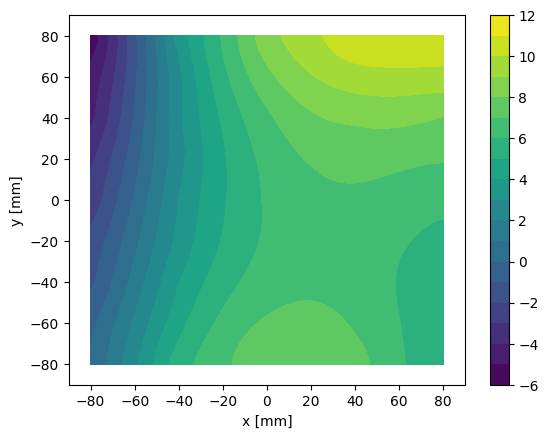

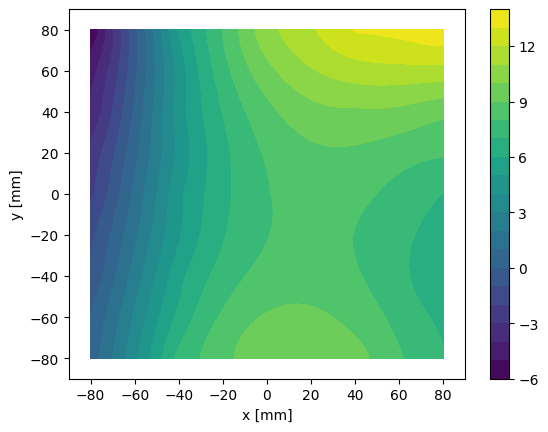

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
for i in range(5):
    B = total_set[25*i:25*i+25, 1]
    x = total_set[25*i:25*i+25, 4]
    y = total_set[25*i:25*i+25, 5]
    
    # 创建网格
    xi = np.linspace(min(x), max(x), 100)
    yi = np.linspace(min(y), max(y), 100)
    xi, yi = np.meshgrid(xi, yi)

    # 使用径向基函数插值
    rbf = Rbf(x, y, B, function='linear')
    zi = rbf(xi, yi)

    # 创建等高线图
    plt.contourf(xi, yi, zi, levels=20, cmap='viridis')
    plt.colorbar(label='')

    # 设置坐标轴标签
    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')

    # 设置坐标轴范围
    plt.xlim(min(x) - 10, max(x) + 10)
    plt.ylim(min(y) - 10, max(y) + 10)

    # 显示图形
    plt.show()

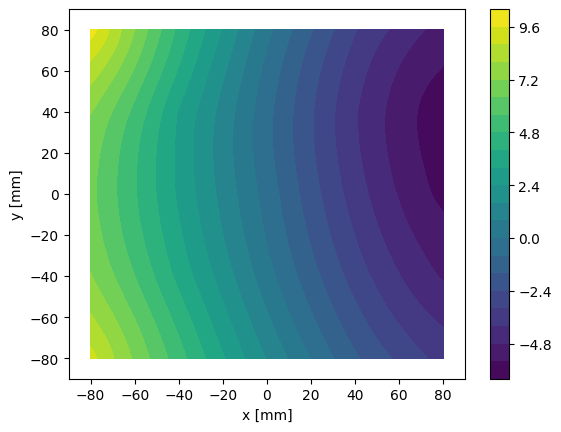

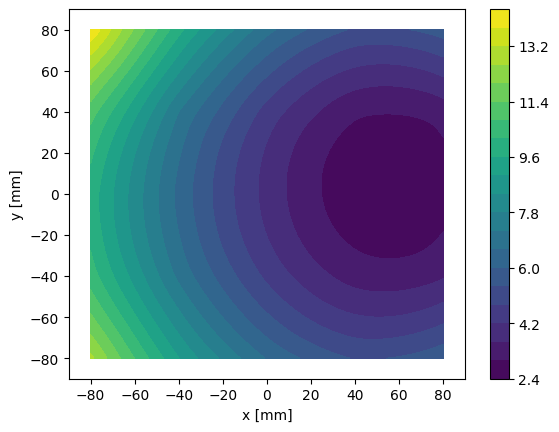

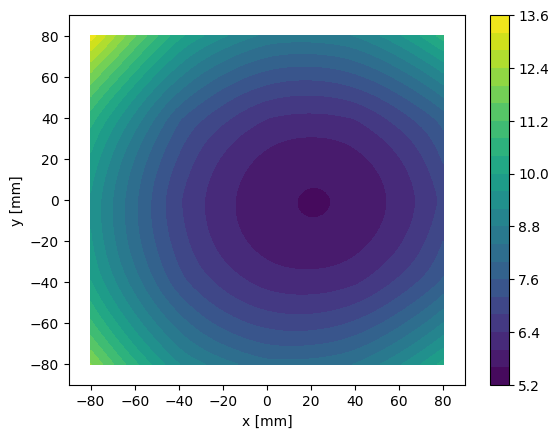

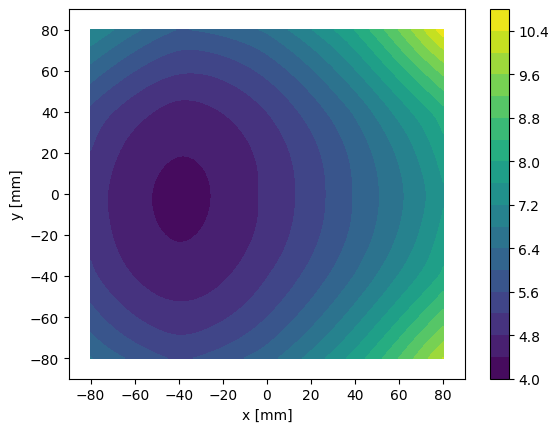

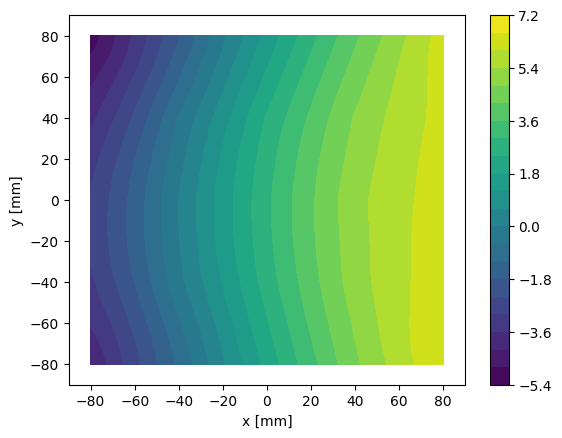

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
for i in range(5):
    B = total_set[25*i:25*i+25, 3]
    x = total_set[25*i:25*i+25, 4]
    y = total_set[25*i:25*i+25, 5]
    
    # 创建网格
    xi = np.linspace(min(x), max(x), 100)
    yi = np.linspace(min(y), max(y), 100)
    xi, yi = np.meshgrid(xi, yi)

    # 使用径向基函数插值
    rbf = Rbf(x, y, B, function='linear')
    zi = rbf(xi, yi)

    # 创建等高线图
    plt.contourf(xi, yi, zi, levels=20, cmap='viridis')
    plt.colorbar(label='')

    # 设置坐标轴标签
    plt.xlabel('x [mm]')
    plt.ylabel('y [mm]')

    # 设置坐标轴范围
    plt.xlim(min(x) - 10, max(x) + 10)
    plt.ylim(min(y) - 10, max(y) + 10)

    # 显示图形
    plt.show()

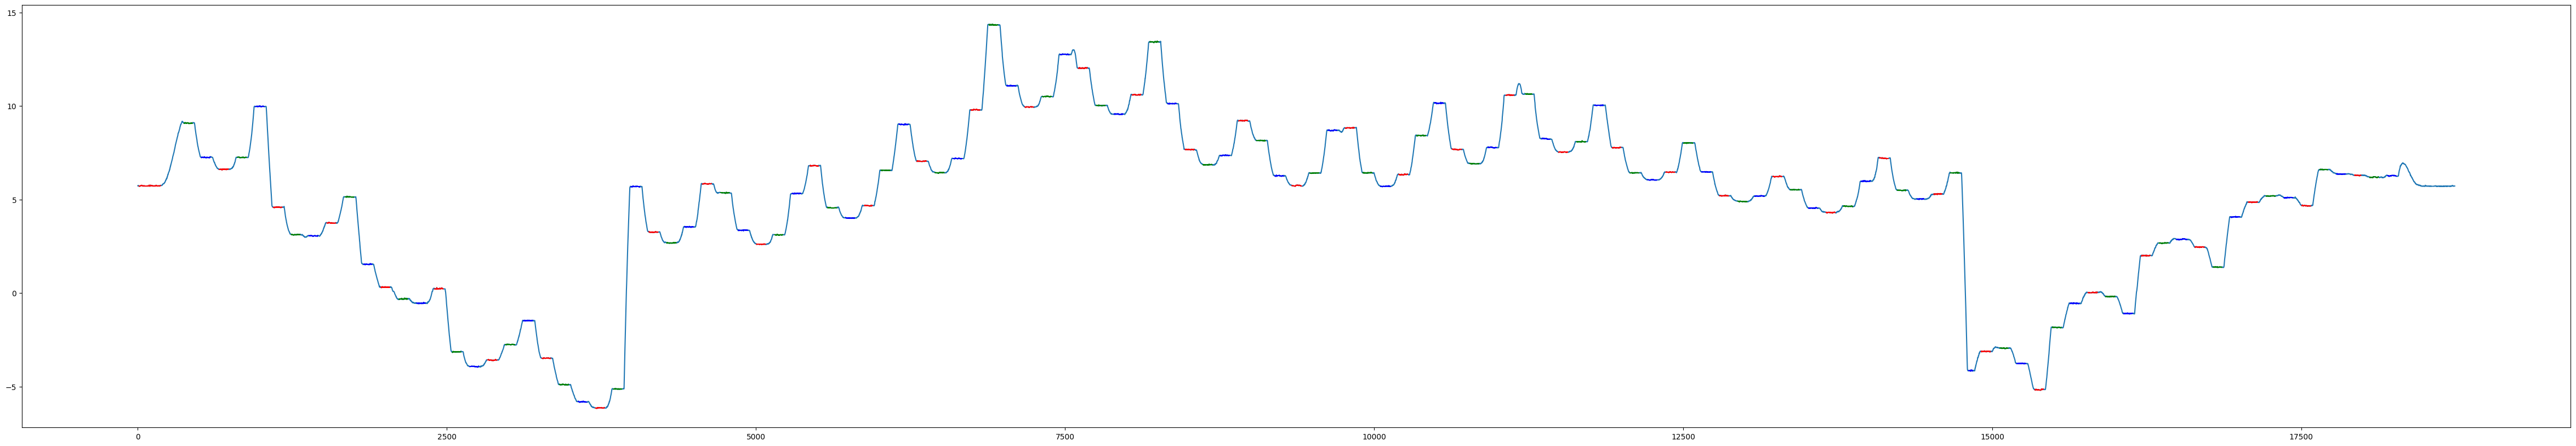

In [16]:
Bx = arm['磁场X(ʯt)'].to_numpy()
By = arm['磁场Y(ʯt)'].to_numpy()
Bz = arm['磁场Z(ʯt)'].to_numpy()
B = arm['磁场矢量和(ʯt)'].to_numpy()
fig=plt.figure(figsize=(60, 10))
plt.plot([i for i in range(len(Bx))], Bx)
col = ['r', 'g', 'b']
for i in range(len(steps)):
    sub = np.array(steps[i])
    plt.plot(sub[10:,0], sub[10:,1], color=col[i%3])